# Trace Count v2.2: Attention Distribution Deep Dive

这个 notebook 不重新训练模型，只加载 v2 main checkpoint，专门回答三个 attention 问题：

1. **non-thinking 的 final-answer attention 到底在哪里？** 是 sink 到 `<BOS>` / `<Ans>`，还是比较均匀地铺在 prompt noise 上，还是集中到 needles？
2. **thinking 的 L3H2 为什么 correct top-1 retrieval 只有约 0.65？** 检查它是不是被 `<BOS>` / self attention / noise 吸走，还是在 prompt needles 之间 off-diagonal 选错。
3. **16 个 heads 的总体 attention 分布长什么样？** 用 head-by-category heatmap 看每个 head 把 attention 分到哪些 token 类别。

记号约定：layer 使用 **1-based** 编号，head 使用 **0-based** 编号。所以截图里的 `L3H2` 对应 `layer=3, head=2`。
        

## 1. Environment and Repo Setup

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import math
import os
import random
import shutil
import subprocess
import sys
from contextlib import contextmanager
from dataclasses import dataclass
from datetime import datetime
from typing import Any

REPO_URL = "https://github.com/Twist-Shan/Synthetic_CoT_NiaH_Count.git"
INSTALL_DEPS = False
FIX_NUMPY_ABI = False  # set True only if pandas/scipy complains about NumPy dtype size

def resolve_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "synthetic_counting_extensions").exists() and (candidate / "notebooks").exists():
            return candidate
        if (candidate / ".git").exists() and (candidate / "notebooks").exists():
            return candidate
    return start


IN_COLAB = "google.colab" in sys.modules or Path("/content").exists()
if IN_COLAB:
    repo_dir = Path("/content/Synthetic_CoT_NiaH_Count")
    cwd = Path.cwd()
    if (cwd / ".git").exists() or (cwd / "notebooks" / "Trace_Count_v2_Colab.ipynb").exists():
        repo_dir = cwd
    elif (cwd.parent / ".git").exists() or (cwd.parent / "synthetic_counting_extensions").exists():
        repo_dir = cwd.parent
    elif (repo_dir / ".git").exists() or (repo_dir / "notebooks" / "Trace_Count_v2_Colab.ipynb").exists():
        pass
    elif repo_dir.exists() and any(repo_dir.iterdir()):
        print(f"Using existing non-git directory: {repo_dir}")
    else:
        subprocess.run(["git", "clone", REPO_URL, str(repo_dir)], check=True)
    os.chdir(repo_dir)

ROOT = resolve_repo_root(Path.cwd())
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

followup_module_path = ROOT / "synthetic_counting_extensions" / "v2_2_followup.py"
if not followup_module_path.exists():
    print(
        "Warning: synthetic_counting_extensions/v2_2_followup.py is missing. "
        "The main v2.2 attention diagnostics can still run, but Section 12 needs the updated repo files. "
        "Run git pull in Colab or upload the latest local repo before running Section 12."
    )

if INSTALL_DEPS:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "transformers>=4.40", "seaborn", "tqdm"],
        check=True,
    )

if FIX_NUMPY_ABI:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "--force-reinstall",
            "numpy<2",
            "pandas",
            "matplotlib",
            "seaborn",
            "scipy",
        ],
        check=True,
    )
    raise RuntimeError("NumPy ABI repair finished. Restart the runtime/kernel, then rerun with FIX_NUMPY_ABI = False.")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import Image, Markdown, display
from tqdm.auto import tqdm
from transformers import GPT2LMHeadModel

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

display(Markdown(f"**Repo root:** `{ROOT}`"))
display(Markdown(f"**Device available:** `{'cuda' if torch.cuda.is_available() else 'cpu'}`"))
        

**Repo root:** `/content/Synthetic_CoT_NiaH_Count`

**Device available:** `cuda`

## 2. Runtime Settings

In [2]:
# Set this if the automatic resolver does not find your v2 run.
# Usually local path:
# V2_RUN_DIR_OVERRIDE = "colab_results/v2_marker_trace_main_seed1234_20260706_215757/run"
# Usually Colab Drive path:
# V2_RUN_DIR_OVERRIDE = "/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results/v2_marker_trace_main_seed1234_20260706_215757/run"
V2_RUN_DIR_OVERRIDE = ""
AUTO_MOUNT_DRIVE_FOR_V2_INPUTS = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RANDOM_SEED = 1234

# Debug: 10-20; main: 100-300. Cost scales linearly with examples_per_count.
EXAMPLES_PER_COUNT = 100

# Main layer from your screenshot. Layer is 1-based; heads are 0-based.
# v2.2 compares all four heads in this layer, not just L3H2.
FOCUS_LAYER = 3

REUSE_EXISTING_TABLES = True
RUN_NON_THINKING_ATTENTION = True
RUN_THINKING_ATTENTION = True

print({
    "V2_RUN_DIR_OVERRIDE": V2_RUN_DIR_OVERRIDE or "<auto>",
    "DEVICE": DEVICE,
    "EXAMPLES_PER_COUNT": EXAMPLES_PER_COUNT,
    "FOCUS_LAYER": FOCUS_LAYER,
})
        

{'V2_RUN_DIR_OVERRIDE': '<auto>', 'DEVICE': 'cuda', 'EXAMPLES_PER_COUNT': 100, 'FOCUS_LAYER': 3}


## 3. v2 Task Rendering Helpers

In [3]:
SPECIAL_TOKENS = ["<PAD>", "<BOS>", "<EOS>", "<Ans>", "<Think/>", "</Think>"]
NOISE_TOKENS = [f"<N{i}>" for i in range(64)]
MARKER_TOKENS = [f"<{chr(ord('A') + i)}>" for i in range(10)]
NUMBER_TOKENS = [f"<{i}>" for i in range(1, 11)]
COUNT_BINS = {"low": {1, 2, 3}, "mid": {4, 5, 6}, "high": {7, 8, 9, 10}}


def count_bin(count: int) -> str:
    for name, values in COUNT_BINS.items():
        if int(count) in values:
            return name
    raise ValueError(count)


@dataclass
class Vocab:
    token_to_id: dict[str, int]
    id_to_token: list[str]

    @classmethod
    def build(cls) -> "Vocab":
        tokens = SPECIAL_TOKENS + NOISE_TOKENS + MARKER_TOKENS + NUMBER_TOKENS
        return cls({tok: i for i, tok in enumerate(tokens)}, tokens)

    @classmethod
    def load(cls, path: Path) -> "Vocab":
        obj = json.loads(path.read_text(encoding="utf-8"))
        return cls(obj["token_to_id"], obj["id_to_token"])

    def encode(self, tokens: list[str]) -> list[int]:
        return [self.token_to_id[tok] for tok in tokens]

    def count_to_token(self, count: int) -> str:
        return f"<{int(count)}>"

    @property
    def pad_id(self) -> int:
        return self.token_to_id["<PAD>"]


@dataclass
class BaseExample:
    seq_tokens: list[str]
    count: int
    needle_positions: list[int]
    needle_markers: list[str]
    seed: int | None = None


def validate_base_example(ex: BaseExample, seq_len: int) -> None:
    assert len(ex.seq_tokens) == seq_len
    assert 1 <= ex.count <= 10
    assert ex.count == len(ex.needle_positions) == len(ex.needle_markers)
    assert ex.needle_positions == sorted(ex.needle_positions)
    assert all(ex.seq_tokens[pos] == marker for pos, marker in zip(ex.needle_positions, ex.needle_markers))
    assert sum(tok in MARKER_TOKENS for tok in ex.seq_tokens) == ex.count


def sample_base_example(seq_len: int, rng: random.Random, *, count: int | None = None, seed: int | None = None) -> BaseExample:
    n = rng.randint(1, 10) if count is None else int(count)
    positions = sorted(rng.sample(range(seq_len), n))
    markers = [rng.choice(MARKER_TOKENS) for _ in range(n)]
    seq = [rng.choice(NOISE_TOKENS) for _ in range(seq_len)]
    for pos, marker in zip(positions, markers):
        seq[pos] = marker
    ex = BaseExample(seq, n, positions, markers, seed)
    validate_base_example(ex, seq_len)
    return ex


def balanced_examples(seq_len: int, examples_per_count: int, seed: int) -> list[BaseExample]:
    rng = random.Random(seed)
    examples = []
    for count in range(1, 11):
        for i in range(examples_per_count):
            examples.append(sample_base_example(seq_len, rng, count=count, seed=seed + 1000 * count + i))
    rng.shuffle(examples)
    return examples


def render_non_thinking(ex: BaseExample, vocab: Vocab) -> dict[str, Any]:
    tokens = ["<BOS>"] + ex.seq_tokens + ["<Ans>", vocab.count_to_token(ex.count), "<EOS>"]
    ans_pos = 1 + len(ex.seq_tokens)
    anchors = {
        "ans_token": ans_pos,
        "final_answer_pos": ans_pos + 1,
        "prompt_start": 1,
        "prompt_end_exclusive": 1 + len(ex.seq_tokens),
        "last_prompt_token": ans_pos - 1,
        "prompt_needle_positions": [1 + p for p in ex.needle_positions],
    }
    return {
        "tokens": tokens,
        "input_ids": vocab.encode(tokens),
        "anchors": anchors,
        "count": ex.count,
        "count_bin": count_bin(ex.count),
        "needle_positions": ex.needle_positions,
        "needle_markers": ex.needle_markers,
    }


def render_thinking(ex: BaseExample, vocab: Vocab) -> dict[str, Any]:
    trace = []
    index_positions = []
    marker_positions = []
    pre_index_positions = []
    think_start_pos = 1 + len(ex.seq_tokens)
    pos = think_start_pos + 1
    prev_marker_pos = think_start_pos
    for k, marker in enumerate(ex.needle_markers, start=1):
        pre_index_positions.append(prev_marker_pos)
        trace.extend([vocab.count_to_token(k), marker])
        index_positions.append(pos)
        marker_positions.append(pos + 1)
        prev_marker_pos = pos + 1
        pos += 2
    tokens = ["<BOS>"] + ex.seq_tokens + ["<Think/>"] + trace + ["</Think>", "<Ans>", vocab.count_to_token(ex.count), "<EOS>"]
    think_end_pos = think_start_pos + 1 + len(trace)
    ans_pos = think_end_pos + 1
    anchors = {
        "think_start": think_start_pos,
        "think_end": think_end_pos,
        "ans_token": ans_pos,
        "final_answer_pos": ans_pos + 1,
        "prompt_start": 1,
        "prompt_end_exclusive": 1 + len(ex.seq_tokens),
        "last_prompt_token": think_start_pos - 1,
        "index_positions": index_positions,
        "marker_positions": marker_positions,
        "pre_index_positions": pre_index_positions,
        "prompt_needle_positions": [1 + p for p in ex.needle_positions],
    }
    return {
        "tokens": tokens,
        "input_ids": vocab.encode(tokens),
        "anchors": anchors,
        "count": ex.count,
        "count_bin": count_bin(ex.count),
        "needle_positions": ex.needle_positions,
        "needle_markers": ex.needle_markers,
    }


def token_role(position: int, rendered: dict[str, Any], ex: BaseExample) -> str:
    a = rendered["anchors"]
    if position == 0:
        return "bos"
    if position in a.get("prompt_needle_positions", []):
        return f"prompt_needle_{a['prompt_needle_positions'].index(position) + 1}"
    if a["prompt_start"] <= position < a["prompt_end_exclusive"]:
        return "prompt_noise"
    if position == a.get("last_prompt_token"):
        return "last_prompt_token"
    if position == a.get("think_start"):
        return "think_open"
    if position in a.get("index_positions", []):
        return f"trace_index_{a['index_positions'].index(position) + 1}"
    if position in a.get("marker_positions", []):
        return f"trace_marker_{a['marker_positions'].index(position) + 1}"
    if position == a.get("think_end"):
        return "think_close"
    if position == a.get("ans_token"):
        return "answer_token"
    if position == a.get("final_answer_pos"):
        return "final_answer"
    return "other_context"
        

## 4. Locate v2 Checkpoint and Load Models

In [4]:
def maybe_mount_drive_for_v2_inputs() -> None:
    if not IN_COLAB or not AUTO_MOUNT_DRIVE_FOR_V2_INPUTS:
        return
    drive_root = Path("/content/drive/MyDrive")
    if drive_root.exists():
        return
    try:
        from google.colab import drive
        print("Mounting Google Drive to search for saved v2 checkpoints...")
        drive.mount("/content/drive")
    except Exception as e:
        print(f"Google Drive mount skipped or failed: {e}")


def candidate_v2_run_dirs() -> list[Path]:
    maybe_mount_drive_for_v2_inputs()
    out = []
    if V2_RUN_DIR_OVERRIDE:
        out.append(Path(V2_RUN_DIR_OVERRIDE))
    out.extend([
        Path("colab_results/v2_marker_trace_main_seed1234_20260706_215757/run"),
        Path("runs/v2_marker_trace_seed1234_main"),
        Path("runs/v2_marker_trace_seed1234_debug"),
    ])
    out.extend(Path("runs").glob("v2_marker_trace_seed*_main"))
    out.extend(Path("runs").glob("v2_marker_trace_seed*_debug"))
    out.extend(Path("colab_results").glob("v2_marker_trace_*_seed*/run"))
    drive_root = Path("/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results")
    if drive_root.exists():
        out.extend(drive_root.glob("v2_marker_trace_*_seed*/run"))
    seen = set()
    deduped = []
    for p in out:
        key = str(p.resolve()) if p.exists() else str(p)
        if key not in seen:
            seen.add(key)
            deduped.append(p)
    return deduped


def resolve_v2_run_dir() -> Path:
    candidates = candidate_v2_run_dirs()
    valid = []
    for p in candidates:
        if (p / "checkpoints" / "final" / "thinking" / "config.json").exists() and (p / "checkpoints" / "final" / "non_thinking" / "config.json").exists():
            valid.append(p)
    if not valid:
        display(pd.DataFrame({"candidate": [str(p) for p in candidates], "exists": [p.exists() for p in candidates]}))
        raise FileNotFoundError(
            "Could not find a v2 final checkpoint. Run Trace_Count_v2_Colab first, copy a v2 bundle into colab_results, "
            "or set V2_RUN_DIR_OVERRIDE to a directory containing checkpoints/final/{thinking,non_thinking}."
        )
    if V2_RUN_DIR_OVERRIDE:
        return valid[0]
    return sorted(valid, key=lambda p: p.stat().st_mtime, reverse=True)[0]


def load_gpt2_eager(path: Path) -> GPT2LMHeadModel:
    try:
        model = GPT2LMHeadModel.from_pretrained(path, attn_implementation="eager")
    except TypeError:
        model = GPT2LMHeadModel.from_pretrained(path)
        model.config._attn_implementation = "eager"
    model.to(DEVICE)
    model.eval()
    return model


V2_RUN_DIR = resolve_v2_run_dir()
CHECKPOINT_DIR = V2_RUN_DIR / "checkpoints" / "final"
VOCAB_PATH = CHECKPOINT_DIR / "vocab.json"
RUN_CONFIG_PATH = V2_RUN_DIR / "config.json"
vocab = Vocab.load(VOCAB_PATH) if VOCAB_PATH.exists() else Vocab.build()
cfg = {"seq_len": 256, "seed": RANDOM_SEED, "device": DEVICE}
if RUN_CONFIG_PATH.exists():
    cfg.update(json.loads(RUN_CONFIG_PATH.read_text(encoding="utf-8")))
cfg["device"] = DEVICE

ANALYSIS_DIR = V2_RUN_DIR / "v2_2_attention_diagnostics"
TABLE_DIR = ANALYSIS_DIR / "tables"
FIG_DIR = ANALYSIS_DIR / "figures"
for p in [ANALYSIS_DIR, TABLE_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

non_model = load_gpt2_eager(CHECKPOINT_DIR / "non_thinking")
think_model = load_gpt2_eager(CHECKPOINT_DIR / "thinking")
N_LAYER = int(think_model.config.n_layer)
N_HEAD = int(think_model.config.n_head)

display(Markdown(f"**v2 run dir:** `{V2_RUN_DIR}`"))
display(Markdown(f"**analysis outputs:** `{ANALYSIS_DIR}`"))
display(Markdown(f"**model:** `{N_LAYER}` layers x `{N_HEAD}` heads, `n_embd={think_model.config.n_embd}`, learned absolute position embeddings."))
        

Mounted at /content/drive


Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

**v2 run dir:** `/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results/v2_marker_trace_main_seed1234_20260706_215757/run`

**analysis outputs:** `/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results/v2_marker_trace_main_seed1234_20260706_215757/run/v2_2_attention_diagnostics`

**model:** `4` layers x `4` heads, `n_embd=256`, learned absolute position embeddings.

## 5. Metric Definitions

**non-thinking query**：最后 prompt 后的 `<Ans>` token。它下一步要预测最终 count。  
**thinking query**：默认看 trace 里的 `index_token_k`，也就是 `<1>, <2>, ..., <n>` 这些计数 token 本身。

几个容易混淆的指标：

- `correct_top1_rate`：只在 **prompt needle positions 之间** 比较，看最高 attention 的 needle 是否是第 k 个 needle。因此如果这个指标低，不是 `<BOS>` 直接造成的；它说明在 needle 集合内部 top-1 选错。
- `diag_share_of_needle_mass`：正确第 k 个 needle 的 attention mass / 所有 prompt needles 的 attention mass。这个值高可以和 raw needle mass 很低同时发生。
- `bos_mass` / `prompt_noise_mass` / `self_mass`：看总 attention 是否被 sink 或非 needle token 吸走。
- `plus_one_score`：对 thinking 的 `index_token_k`，看它是否主要看前一个 trace index/marker；如果高，更像局部 `+1` continuation。
        

In [5]:
def attention_entropy(weights: np.ndarray) -> float:
    p = weights / max(float(weights.sum()), 1e-12)
    p = p[p > 0]
    return float(-(p * np.log(p)).sum())


def mass(weights: np.ndarray, positions: set[int] | list[int]) -> float:
    positions = [int(p) for p in positions if 0 <= int(p) < len(weights)]
    return float(weights[positions].sum()) if positions else 0.0


def disjoint_mass(weights: np.ndarray, named_positions: list[tuple[str, set[int] | list[int]]]) -> dict[str, float]:
    assigned: set[int] = set()
    out = {}
    for name, positions in named_positions:
        pos_set = {int(p) for p in positions if 0 <= int(p) < len(weights)} - assigned
        out[name] = mass(weights, pos_set)
        assigned |= pos_set
    out["other_context_mass"] = max(0.0, 1.0 - sum(out.values()))
    return out


def heatmap_layer_head(df: pd.DataFrame, metric: str, title: str, filename: str, vmin: float | None = None, vmax: float | None = None, cmap: str = "viridis") -> None:
    mat = df.pivot(index="layer", columns="head", values=metric)
    plt.figure(figsize=(5.8, 4.4))
    sns.heatmap(mat, annot=True, fmt=".2f", cmap=cmap, vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.xlabel("head")
    plt.ylabel("layer")
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, bbox_inches="tight", dpi=180)
    plt.show()
        

## 6. Non-thinking Attention: BOS Sink or Uniform Noise?

这里每个样本只看 non-thinking 模型的 `<Ans>` query。

图的含义：
- 热图横轴是 head，纵轴是 layer。
- 颜色是该 head 平均 attention mass 或 entropy。
- `bos_mass` 高说明 attention sink 到 `<BOS>`；`prompt_noise_mass` 高且 normalized entropy 高说明更像铺在 noise 上；`all_prompt_needles_mass` 高说明直接把注意力放到 needles。
        

In [6]:
NON_CATEGORIES = [
    "bos_mass",
    "ans_self_mass",
    "last_prompt_token_mass",
    "prompt_needles_mass",
    "prompt_noise_mass",
    "other_context_mass",
]


@torch.no_grad()
def collect_non_thinking_attention(model: GPT2LMHeadModel, examples: list[BaseExample]) -> pd.DataFrame:
    rows = []
    for ex_i, ex in enumerate(tqdm(examples, desc="non-thinking attention")):
        r = render_non_thinking(ex, vocab)
        input_ids = torch.tensor([r["input_ids"]], dtype=torch.long, device=DEVICE)
        attention_mask = torch.ones_like(input_ids)
        out = model(input_ids=input_ids, attention_mask=attention_mask, output_attentions=True, use_cache=False)
        attentions = [a.detach().float().cpu().numpy()[0] for a in out.attentions]
        a = r["anchors"]
        q = a["ans_token"]
        prompt_positions = list(range(a["prompt_start"], a["prompt_end_exclusive"]))
        prompt_needles = set(a["prompt_needle_positions"])
        prompt_noise = set(prompt_positions) - prompt_needles
        last_prompt = {a["last_prompt_token"]}
        for layer_idx, attn in enumerate(attentions, start=1):
            for head in range(attn.shape[0]):
                weights = attn[head, q, :]
                cats = disjoint_mass(
                    weights,
                    [
                        ("bos_mass", {0}),
                        ("ans_self_mass", {q}),
                        ("last_prompt_token_mass", last_prompt),
                        ("prompt_needles_mass", prompt_needles),
                        ("prompt_noise_mass", prompt_noise),
                    ],
                )
                top_pos = int(np.argmax(weights))
                prompt_weights = weights[prompt_positions]
                top_prompt_pos = prompt_positions[int(np.argmax(prompt_weights))]
                top_n_prompt = np.array(prompt_positions)[np.argsort(prompt_weights)[-ex.count:]]
                rows.append({
                    "example_id": ex_i,
                    "count": ex.count,
                    "count_bin": count_bin(ex.count),
                    "layer": layer_idx,
                    "head": head,
                    "query_anchor": "ans_token",
                    "top_position": top_pos,
                    "top_token": r["tokens"][top_pos],
                    "top_role": token_role(top_pos, r, ex),
                    "top_prompt_position": int(top_prompt_pos),
                    "top_prompt_role": token_role(int(top_prompt_pos), r, ex),
                    "top_n_retrieval_recall": len(set(top_n_prompt.tolist()) & prompt_needles) / ex.count,
                    "prompt_entropy": attention_entropy(prompt_weights),
                    "prompt_entropy_normalized": attention_entropy(prompt_weights) / math.log(len(prompt_positions)),
                    "needle_per_token_mass": mass(weights, prompt_needles) / max(len(prompt_needles), 1),
                    "noise_per_token_mass": mass(weights, prompt_noise) / max(len(prompt_noise), 1),
                    **cats,
                })
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return pd.DataFrame(rows)


non_path = TABLE_DIR / "nonthinking_attention_rows.csv"
examples = balanced_examples(int(cfg["seq_len"]), EXAMPLES_PER_COUNT, RANDOM_SEED + 2201)
if RUN_NON_THINKING_ATTENTION:
    if REUSE_EXISTING_TABLES and non_path.exists():
        non_df = pd.read_csv(non_path)
    else:
        non_df = collect_non_thinking_attention(non_model, examples)
        non_df.to_csv(non_path, index=False)
else:
    non_df = pd.read_csv(non_path)

non_head = (
    non_df.groupby(["layer", "head"], as_index=False)
    .agg(
        bos_mass=("bos_mass", "mean"),
        ans_self_mass=("ans_self_mass", "mean"),
        last_prompt_token_mass=("last_prompt_token_mass", "mean"),
        prompt_needles_mass=("prompt_needles_mass", "mean"),
        prompt_noise_mass=("prompt_noise_mass", "mean"),
        other_context_mass=("other_context_mass", "mean"),
        top_n_retrieval_recall=("top_n_retrieval_recall", "mean"),
        prompt_entropy_normalized=("prompt_entropy_normalized", "mean"),
        needle_per_token_mass=("needle_per_token_mass", "mean"),
        noise_per_token_mass=("noise_per_token_mass", "mean"),
    )
)
non_head.to_csv(TABLE_DIR / "nonthinking_head_summary.csv", index=False)

display(Markdown(f"Saved: `{non_path}`"))
display(non_head.sort_values("prompt_needles_mass", ascending=False).head(10))
        

Saved: `/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results/v2_marker_trace_main_seed1234_20260706_215757/run/v2_2_attention_diagnostics/tables/nonthinking_attention_rows.csv`

,layer,head,bos_mass,ans_self_mass,last_prompt_token_mass,prompt_needles_mass,prompt_noise_mass,other_context_mass,top_n_retrieval_recall,prompt_entropy_normalized,needle_per_token_mass,noise_per_token_mass
2,1,2,0.004447,0.004917,0.003480,0.109933,0.877223,2.032309e-08,1.000000,0.981446,0.020574,0.003512
1,1,1,0.003590,0.004642,0.003456,0.104795,0.883518,1.963112e-08,1.000000,0.982953,0.019588,0.003537
3,1,3,0.004894,0.006180,0.003596,0.103809,0.881521,1.834612e-08,1.000000,0.983266,0.019446,0.003530
0,1,0,0.004176,0.007022,0.003692,0.090024,0.895086,1.963763e-08,1.000000,0.987173,0.016758,0.003585
8,3,0,0.004155,0.111849,0.008834,0.031897,0.843265,2.766329e-08,0.070460,0.693875,0.005615,0.003397
13,4,1,0.010553,0.003348,0.003686,0.029940,0.952472,2.544058e-08,0.051075,0.925119,0.004930,0.003816
11,3,3,0.024317,0.056393,0.003103,0.023878,0.892309,2.185573e-08,0.080550,0.876960,0.004211,0.003571
9,3,1,0.031768,0.057293,0.003377,0.023277,0.884284,2.150449e-08,0.058603,0.859864,0.004175,0.003539
10,3,2,0.018762,0.016874,0.003719,0.023126,0.937519,2.169708e-08,0.050932,0.958497,0.004135,0.003756
6,2,2,0.004423,0.003607,0.004239,0.021351,0.966380,2.007675e-08,0.051792,0.999037,0.003902,0.003874


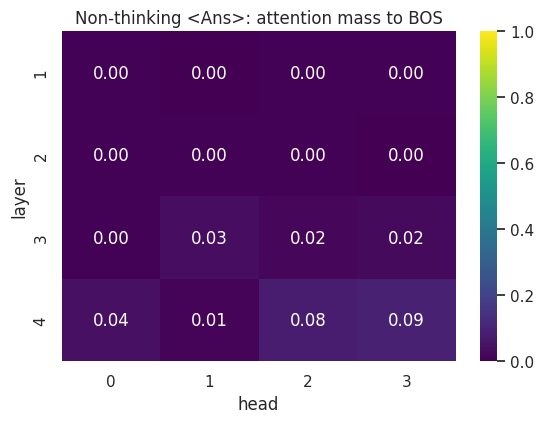

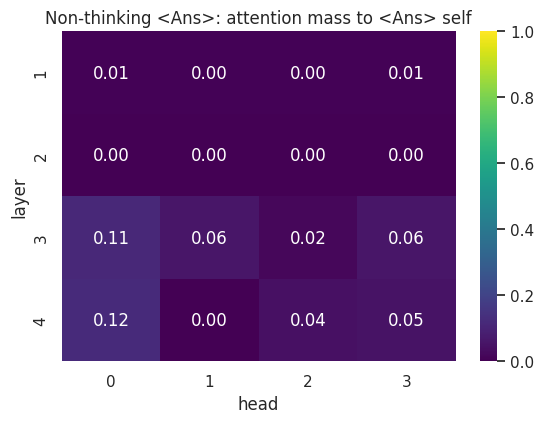

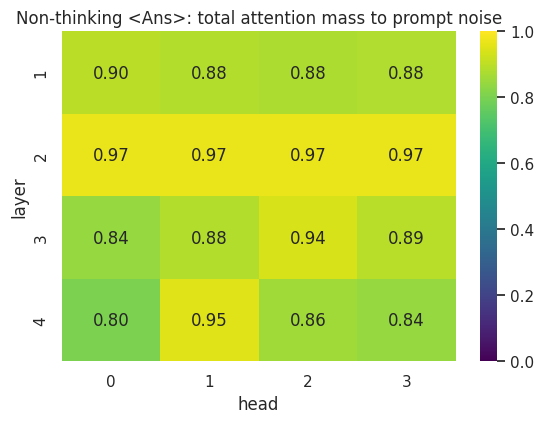

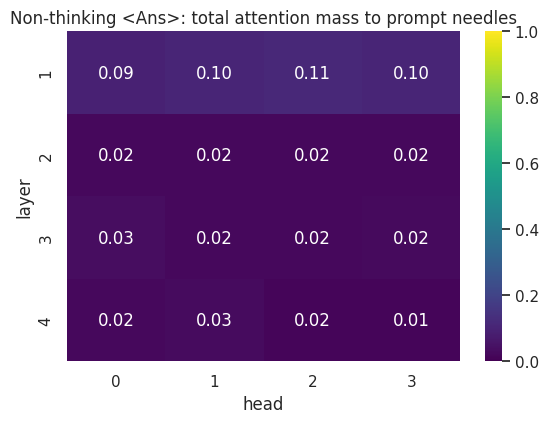

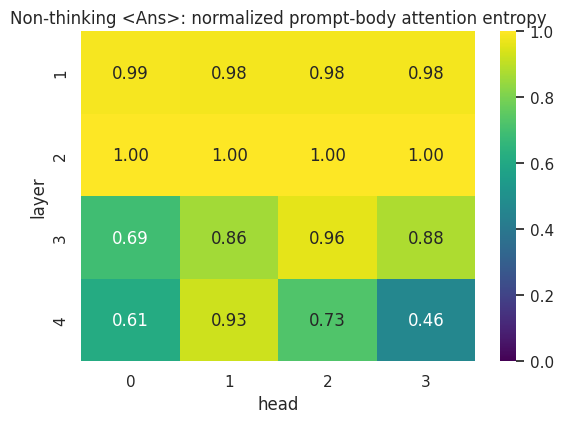

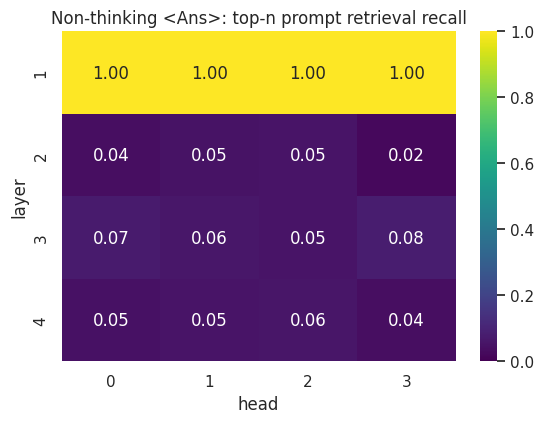

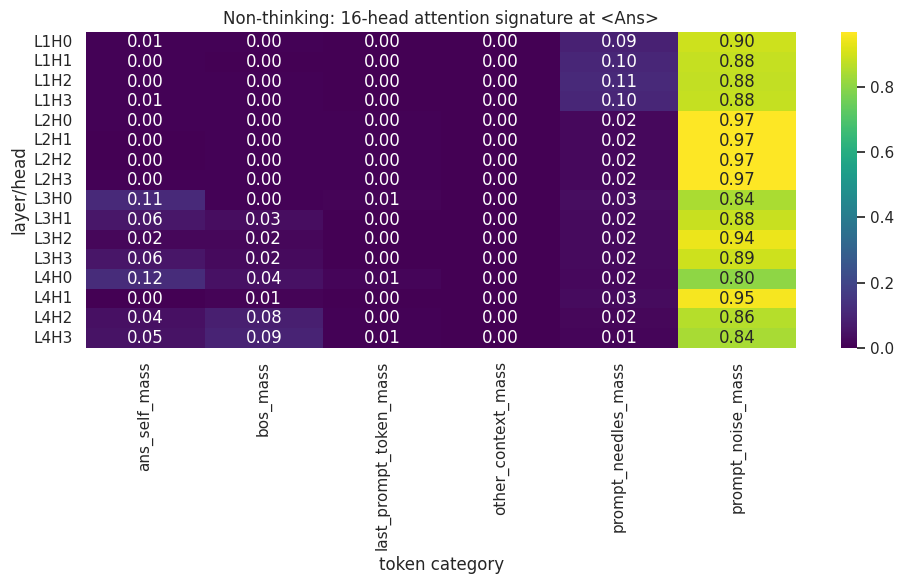

**Most common overall top-attended role per non-thinking head.**

,layer,head,top_role,size
0,1,0,prompt_needle_1,275
2,1,0,prompt_needle_2,167
3,1,0,prompt_needle_3,145
10,1,1,prompt_needle_1,267
12,1,1,prompt_needle_2,179
13,1,1,prompt_needle_3,151
20,1,2,prompt_needle_1,247
22,1,2,prompt_needle_2,182
23,1,2,prompt_needle_3,160
30,1,3,prompt_needle_1,278


In [7]:
for metric, title, fname, vmax in [
    ("bos_mass", "Non-thinking <Ans>: attention mass to BOS", "nonthinking_bos_mass_by_head.png", 1.0),
    ("ans_self_mass", "Non-thinking <Ans>: attention mass to <Ans> self", "nonthinking_ans_self_mass_by_head.png", 1.0),
    ("prompt_noise_mass", "Non-thinking <Ans>: total attention mass to prompt noise", "nonthinking_prompt_noise_mass_by_head.png", 1.0),
    ("prompt_needles_mass", "Non-thinking <Ans>: total attention mass to prompt needles", "nonthinking_prompt_needles_mass_by_head.png", 1.0),
    ("prompt_entropy_normalized", "Non-thinking <Ans>: normalized prompt-body attention entropy", "nonthinking_prompt_entropy_by_head.png", 1.0),
    ("top_n_retrieval_recall", "Non-thinking <Ans>: top-n prompt retrieval recall", "nonthinking_topn_recall_by_head.png", 1.0),
]:
    heatmap_layer_head(non_head, metric, title, fname, vmin=0.0, vmax=vmax)

sig = non_head.copy()
sig["head_label"] = "L" + sig["layer"].astype(str) + "H" + sig["head"].astype(str)
sig_long = sig.melt(id_vars=["head_label"], value_vars=NON_CATEGORIES, var_name="category", value_name="attention_mass")
pivot = sig_long.pivot(index="head_label", columns="category", values="attention_mass")
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, cmap="viridis", annot=True, fmt=".2f", vmin=0, vmax=max(0.05, float(pivot.max().max())))
plt.title("Non-thinking: 16-head attention signature at <Ans>")
plt.xlabel("token category")
plt.ylabel("layer/head")
plt.tight_layout()
plt.savefig(FIG_DIR / "nonthinking_16head_category_signature.png", bbox_inches="tight", dpi=180)
plt.show()

top_role = (
    non_df.groupby(["layer", "head", "top_role"], as_index=False)
    .size()
    .sort_values(["layer", "head", "size"], ascending=[True, True, False])
)
display(Markdown("**Most common overall top-attended role per non-thinking head.**"))
display(top_role.groupby(["layer", "head"]).head(3))
        

## 7. Thinking Attention: Why is L3H2 top-1 only around 0.65?

这里默认只看 thinking trace 的 `index_token_k` query，也就是 `<k>` 本身。

图的含义：
- `correct_top1_rate`：只在 prompt needles 之间排名，看最高的 needle 是否是第 k 个 needle。
- `diag_share_of_needle_mass`：正确 needle 占所有 needle attention mass 的比例。
- `correct_prompt_needle_mass`：raw attention mass 到第 k 个 prompt needle。
- `bos_mass` / `current_index_self_mass` / `prompt_noise_mass`：检查是否有 attention sink 或 self/noise 抢走总 attention。
        

In [8]:
THINK_CATEGORIES = [
    "bos_mass",
    "think_open_mass",
    "current_index_self_mass",
    "correct_prompt_needle_mass",
    "other_prompt_needles_mass",
    "prompt_noise_mass",
    "previous_index_token_mass",
    "previous_marker_token_mass",
    "earlier_trace_index_mass",
    "earlier_trace_marker_mass",
    "other_context_mass",
]


@torch.no_grad()
def collect_thinking_index_attention(model: GPT2LMHeadModel, examples: list[BaseExample]) -> pd.DataFrame:
    rows = []
    for ex_i, ex in enumerate(tqdm(examples, desc="thinking index attention")):
        r = render_thinking(ex, vocab)
        input_ids = torch.tensor([r["input_ids"]], dtype=torch.long, device=DEVICE)
        attention_mask = torch.ones_like(input_ids)
        out = model(input_ids=input_ids, attention_mask=attention_mask, output_attentions=True, use_cache=False)
        attentions = [a.detach().float().cpu().numpy()[0] for a in out.attentions]
        a = r["anchors"]
        prompt_positions = set(range(a["prompt_start"], a["prompt_end_exclusive"]))
        prompt_needles = list(a["prompt_needle_positions"])
        prompt_noise = prompt_positions - set(prompt_needles)
        for k, q in enumerate(a["index_positions"], start=1):
            correct_needle = {prompt_needles[k - 1]}
            other_needles = set(prompt_needles) - correct_needle
            previous_index = {a["index_positions"][k - 2]} if k > 1 else set()
            previous_marker = {a["marker_positions"][k - 2]} if k > 1 else set()
            earlier_index = set(a["index_positions"][: max(k - 1, 0)]) - previous_index
            earlier_marker = set(a["marker_positions"][: max(k - 1, 0)]) - previous_marker
            for layer_idx, attn in enumerate(attentions, start=1):
                for head in range(attn.shape[0]):
                    weights = attn[head, q, :]
                    cats = disjoint_mass(
                        weights,
                        [
                            ("bos_mass", {0}),
                            ("think_open_mass", {a["think_start"]}),
                            ("current_index_self_mass", {q}),
                            ("correct_prompt_needle_mass", correct_needle),
                            ("other_prompt_needles_mass", other_needles),
                            ("prompt_noise_mass", prompt_noise),
                            ("previous_index_token_mass", previous_index),
                            ("previous_marker_token_mass", previous_marker),
                            ("earlier_trace_index_mass", earlier_index),
                            ("earlier_trace_marker_mass", earlier_marker),
                        ],
                    )
                    needle_weights = weights[prompt_needles]
                    top_needle_idx = int(np.argmax(needle_weights)) + 1
                    all_needle_mass = float(needle_weights.sum())
                    top_pos = int(np.argmax(weights))
                    rows.append({
                        "example_id": ex_i,
                        "count": ex.count,
                        "count_bin": count_bin(ex.count),
                        "k": k,
                        "is_last_index": bool(k == ex.count),
                        "layer": layer_idx,
                        "head": head,
                        "query_anchor": "index_token_k",
                        "query_token": r["tokens"][q],
                        "query_position": int(q),
                        "top_position": top_pos,
                        "top_token": r["tokens"][top_pos],
                        "top_role": token_role(top_pos, r, ex),
                        "top_prompt_needle_index": top_needle_idx,
                        "correct_top1_rate": float(top_needle_idx == k),
                        "all_prompt_needles_mass": all_needle_mass,
                        "diag_share_of_needle_mass": float(weights[prompt_needles[k - 1]] / (all_needle_mass + 1e-12)),
                        "plus_one_score": cats["previous_index_token_mass"] + cats["previous_marker_token_mass"],
                        **cats,
                    })
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return pd.DataFrame(rows)


think_path = TABLE_DIR / "thinking_index_attention_rows.csv"
if RUN_THINKING_ATTENTION:
    if REUSE_EXISTING_TABLES and think_path.exists():
        think_df = pd.read_csv(think_path)
    else:
        think_df = collect_thinking_index_attention(think_model, examples)
        think_df.to_csv(think_path, index=False)
else:
    think_df = pd.read_csv(think_path)

think_head = (
    think_df.groupby(["layer", "head"], as_index=False)
    .agg(
        correct_top1_rate=("correct_top1_rate", "mean"),
        diag_share_of_needle_mass=("diag_share_of_needle_mass", "mean"),
        correct_prompt_needle_mass=("correct_prompt_needle_mass", "mean"),
        all_prompt_needles_mass=("all_prompt_needles_mass", "mean"),
        bos_mass=("bos_mass", "mean"),
        current_index_self_mass=("current_index_self_mass", "mean"),
        prompt_noise_mass=("prompt_noise_mass", "mean"),
        previous_index_token_mass=("previous_index_token_mass", "mean"),
        previous_marker_token_mass=("previous_marker_token_mass", "mean"),
        plus_one_score=("plus_one_score", "mean"),
    )
)
think_head.to_csv(TABLE_DIR / "thinking_index_head_summary.csv", index=False)

display(Markdown(f"Saved: `{think_path}`"))
display(think_head.sort_values(["correct_top1_rate", "diag_share_of_needle_mass"], ascending=False).head(16))
        

Saved: `/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results/v2_marker_trace_main_seed1234_20260706_215757/run/v2_2_attention_diagnostics/tables/thinking_index_attention_rows.csv`

,layer,head,correct_top1_rate,diag_share_of_needle_mass,correct_prompt_needle_mass,all_prompt_needles_mass,bos_mass,current_index_self_mass,prompt_noise_mass,previous_index_token_mass,previous_marker_token_mass,plus_one_score
11,3,3,0.999273,0.887443,0.830762,0.936218,0.000085,0.000255,0.059065,0.000048,0.001387,0.001435
9,3,1,0.975455,0.864430,0.655686,0.739216,0.000799,0.001331,0.252420,0.000353,0.000650,0.001003
8,3,0,0.822182,0.791958,0.062484,0.063546,0.000005,0.005139,0.930980,0.000313,0.000007,0.000320
12,4,0,0.746182,0.611560,0.013397,0.016430,0.000040,0.000079,0.982358,0.000025,0.000376,0.000402
13,4,1,0.735455,0.590909,0.039246,0.053477,0.000149,0.000710,0.942715,0.000142,0.000138,0.000280
10,3,2,0.585273,0.591302,0.094974,0.096963,0.000012,0.001308,0.901484,0.000226,0.000003,0.000230
5,2,1,0.492545,0.399547,0.001423,0.002372,0.001148,0.043223,0.934395,0.017002,0.000132,0.017134
14,4,2,0.451818,0.394498,0.005137,0.012772,0.011182,0.053793,0.700537,0.167480,0.000831,0.168311
7,2,3,0.365455,0.398837,0.090016,0.254100,0.000375,0.003226,0.546433,0.000449,0.159841,0.160289
6,2,2,0.350000,0.292378,0.018608,0.062338,0.002392,0.003542,0.916100,0.003526,0.001614,0.005140


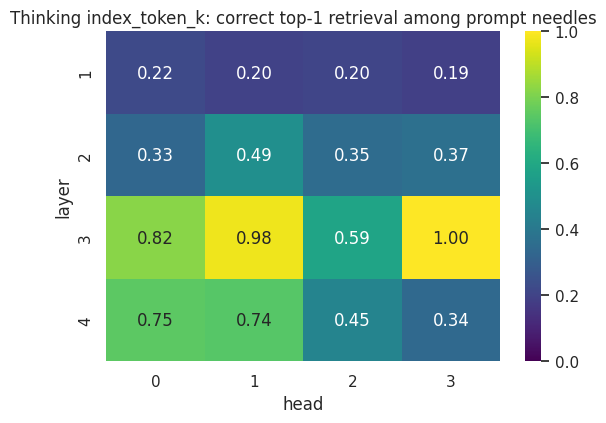

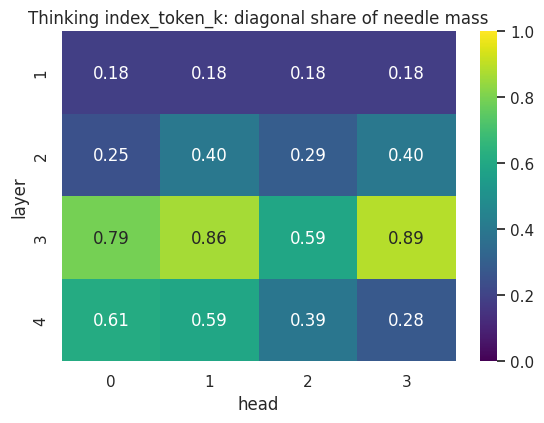

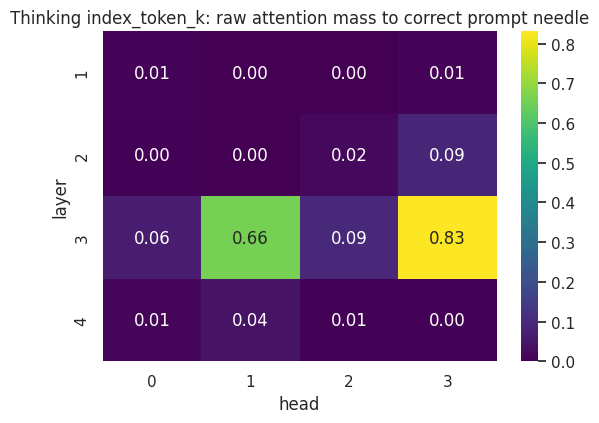

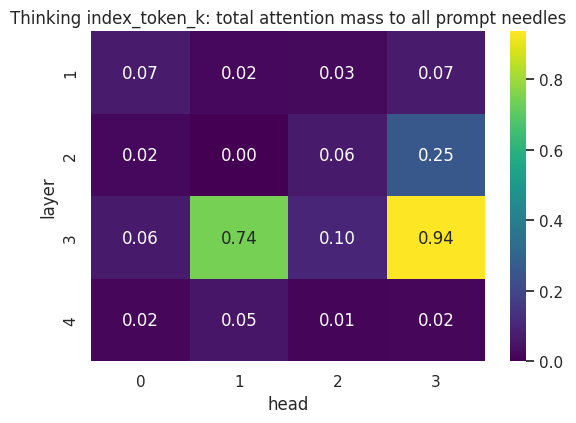

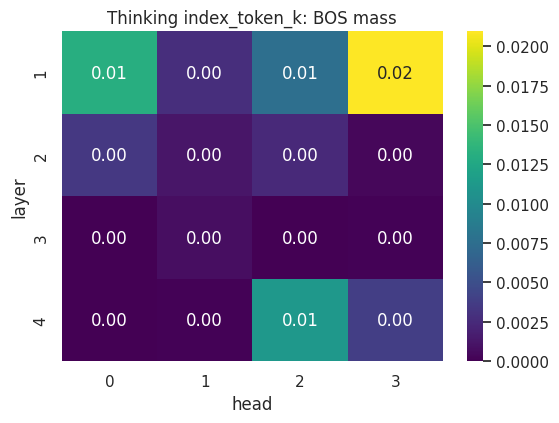

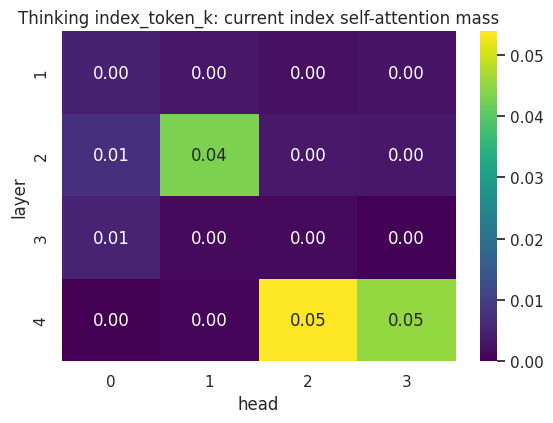

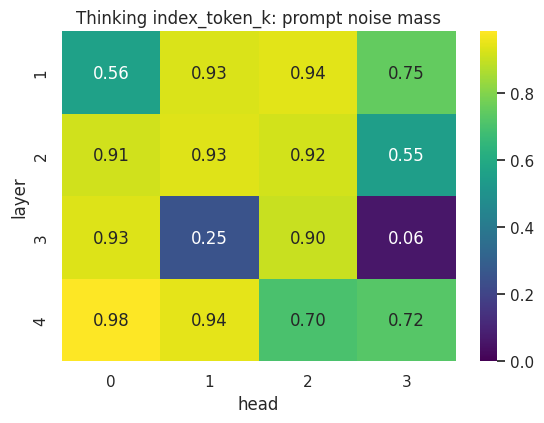

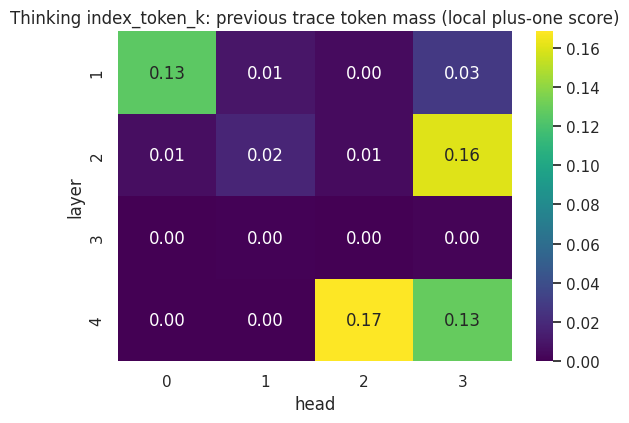

In [9]:
for metric, title, fname, vmax in [
    ("correct_top1_rate", "Thinking index_token_k: correct top-1 retrieval among prompt needles", "thinking_index_correct_top1_by_head.png", 1.0),
    ("diag_share_of_needle_mass", "Thinking index_token_k: diagonal share of needle mass", "thinking_index_diag_share_by_head.png", 1.0),
    ("correct_prompt_needle_mass", "Thinking index_token_k: raw attention mass to correct prompt needle", "thinking_index_correct_needle_mass_by_head.png", None),
    ("all_prompt_needles_mass", "Thinking index_token_k: total attention mass to all prompt needles", "thinking_index_all_needles_mass_by_head.png", None),
    ("bos_mass", "Thinking index_token_k: BOS mass", "thinking_index_bos_mass_by_head.png", None),
    ("current_index_self_mass", "Thinking index_token_k: current index self-attention mass", "thinking_index_self_mass_by_head.png", None),
    ("prompt_noise_mass", "Thinking index_token_k: prompt noise mass", "thinking_index_prompt_noise_mass_by_head.png", None),
    ("plus_one_score", "Thinking index_token_k: previous trace token mass (local plus-one score)", "thinking_index_plus_one_score_by_head.png", None),
]:
    heatmap_layer_head(think_head, metric, title, fname, vmin=0.0, vmax=vmax)
        

## 8. Layer 3 Head-by-Head Diagnostics

这一节不只看 L3H2，而是把 **Layer 3 的四个 head（H0-H3）** 放在一起比较。这样可以判断：

- L3H2 的 `correct_top1_rate≈0.65` 是不是因为 BOS sink / self attention / noise 抢走了总 attention。
- L3 其他 head 是否承担了更清楚的 targeted retrieval。
- “diagonal dominance 高”到底来自真正看对 prompt needle，还是来自 needle 内部的平均 diagonal share 但 top-1 经常被别的 needle 抢走。

表格字段说明：

- `correct_top1_rate`：在 prompt needles 内部排名，最高 attention 的 needle 是否等于当前 trace 的第 k 个 needle。
- `diag_share_of_needle_mass`：correct needle mass / all needle mass。这个高说明 needle mass 比较 diagonal，但不保证总 attention 很大。
- `correct_prompt_needle_mass` / `all_prompt_needles_mass`：绝对 attention mass，能判断这个 head 到底有没有真正看 prompt needles。
- `bos_mass`、`current_index_self_mass`、`prompt_noise_mass`、`plus_one_score`：分别对应 BOS sink、看当前 trace 数字自己、看 prompt noise、看前一个 trace 数字/marker 的局部 +1 线索。
        

,subset,layer,head,n_queries,correct_top1_rate,diag_share_of_needle_mass,correct_prompt_needle_mass,all_prompt_needles_mass,bos_mass,current_index_self_mass,prompt_noise_mass,previous_index_token_mass,previous_marker_token_mass,plus_one_score
0,all_index_tokens,3,0,5500,0.822182,0.791958,0.062484,0.063546,0.000005,0.005139,0.930980,0.000313,0.000007,0.000320
1,all_index_tokens,3,1,5500,0.975455,0.864430,0.655686,0.739216,0.000799,0.001331,0.252420,0.000353,0.000650,0.001003
2,all_index_tokens,3,2,5500,0.585273,0.591302,0.094974,0.096963,0.000012,0.001308,0.901484,0.000226,0.000003,0.000230
3,all_index_tokens,3,3,5500,0.999273,0.887443,0.830762,0.936218,0.000085,0.000255,0.059065,0.000048,0.001387,0.001435
4,last_index_only,3,0,1000,0.665000,0.645131,0.106976,0.107870,0.000013,0.025844,0.865814,0.000363,0.000038,0.000400
5,last_index_only,3,1,1000,0.903000,0.809914,0.499835,0.578210,0.004247,0.005349,0.382864,0.000684,0.003530,0.004214
6,last_index_only,3,2,1000,0.292000,0.337191,0.122244,0.125735,0.000018,0.006732,0.866873,0.000607,0.000018,0.000625
7,last_index_only,3,3,1000,1.000000,0.912669,0.840086,0.921564,0.000220,0.001110,0.056063,0.000156,0.007608,0.007763


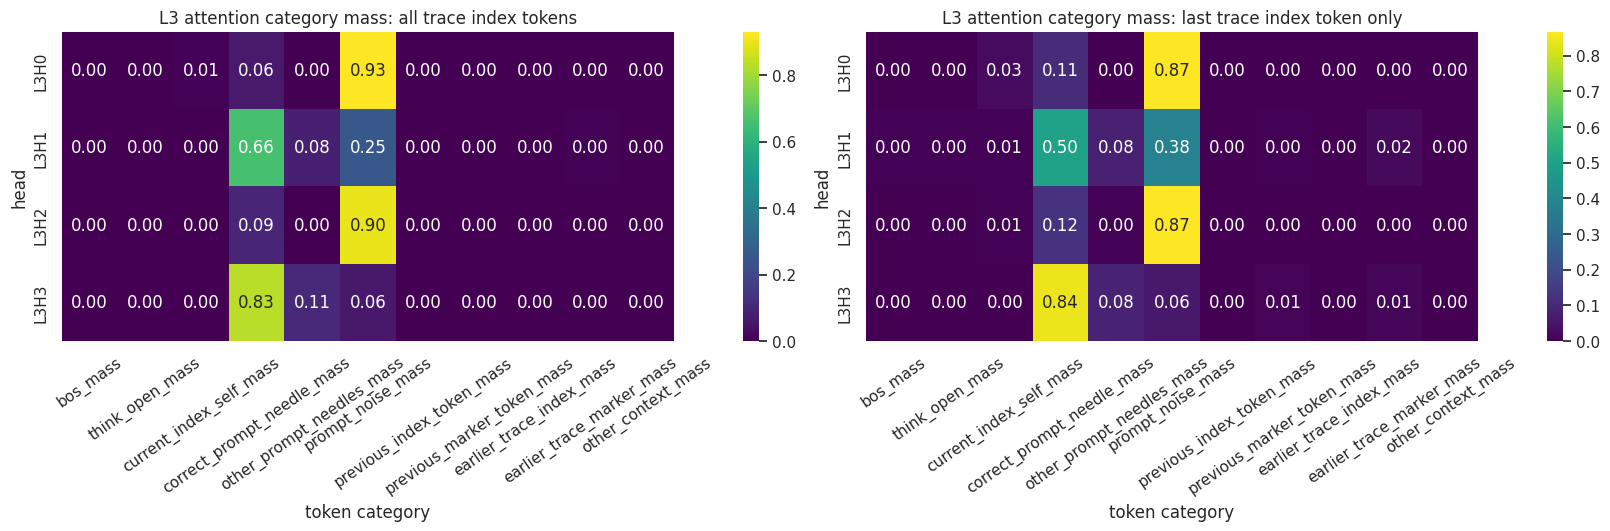

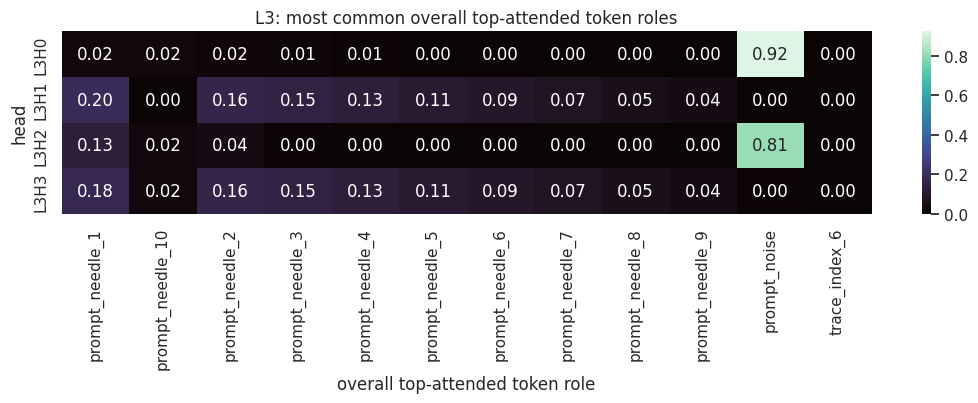

In [10]:
layer_focus = think_df[think_df["layer"] == FOCUS_LAYER].copy()
layer_focus_last = layer_focus[layer_focus["is_last_index"]].copy()

summary_cols = [
    "correct_top1_rate",
    "diag_share_of_needle_mass",
    "correct_prompt_needle_mass",
    "all_prompt_needles_mass",
    "bos_mass",
    "current_index_self_mass",
    "prompt_noise_mass",
    "previous_index_token_mass",
    "previous_marker_token_mass",
    "plus_one_score",
]

def summarize_layer_heads(df: pd.DataFrame, subset: str) -> pd.DataFrame:
    out = (
        df.groupby(["layer", "head"], as_index=False)
        .agg(n_queries=("k", "size"), **{c: (c, "mean") for c in summary_cols})
    )
    out.insert(0, "subset", subset)
    return out

layer_summary = pd.concat(
    [
        summarize_layer_heads(layer_focus, "all_index_tokens"),
        summarize_layer_heads(layer_focus_last, "last_index_only"),
    ],
    ignore_index=True,
).sort_values(["subset", "head"])

layer_summary.to_csv(TABLE_DIR / f"thinking_L{FOCUS_LAYER}_head_summary.csv", index=False)
display(layer_summary)


def category_pivot(df: pd.DataFrame) -> pd.DataFrame:
    cat = df.groupby("head", as_index=False)[THINK_CATEGORIES].mean()
    cat["head_label"] = "L" + str(FOCUS_LAYER) + "H" + cat["head"].astype(str)
    return cat.set_index("head_label")[THINK_CATEGORIES]

cat_all = category_pivot(layer_focus)
cat_last = category_pivot(layer_focus_last)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.2), constrained_layout=True)
for ax, mat, title in [
    (axes[0], cat_all, "all trace index tokens"),
    (axes[1], cat_last, "last trace index token only"),
]:
    sns.heatmap(mat, ax=ax, cmap="viridis", annot=True, fmt=".2f", vmin=0, vmax=max(0.05, float(mat.max().max())))
    ax.set_title(f"L{FOCUS_LAYER} attention category mass: {title}")
    ax.set_xlabel("token category")
    ax.set_ylabel("head")
    ax.tick_params(axis="x", rotation=35)

plt.savefig(FIG_DIR / f"thinking_L{FOCUS_LAYER}_all_heads_category_mass.png", bbox_inches="tight", dpi=180)
plt.show()

role_counts = (
    layer_focus.groupby(["head", "top_role"], as_index=False)
    .size()
    .assign(frac=lambda d: d["size"] / d.groupby("head")["size"].transform("sum"))
)
top_roles = role_counts.sort_values("size", ascending=False)["top_role"].drop_duplicates().head(12).tolist()
role_mat = (
    role_counts[role_counts["top_role"].isin(top_roles)]
    .pivot(index="head", columns="top_role", values="frac")
    .fillna(0.0)
)
role_mat.index = [f"L{FOCUS_LAYER}H{h}" for h in role_mat.index]

plt.figure(figsize=(11, 4.2))
sns.heatmap(role_mat, cmap="mako", annot=True, fmt=".2f", vmin=0, vmax=max(0.05, float(role_mat.max().max())))
plt.title(f"L{FOCUS_LAYER}: most common overall top-attended token roles")
plt.xlabel("overall top-attended token role")
plt.ylabel("head")
plt.tight_layout()
plt.savefig(FIG_DIR / f"thinking_L{FOCUS_LAYER}_top_roles_by_head.png", bbox_inches="tight", dpi=180)
plt.show()
        

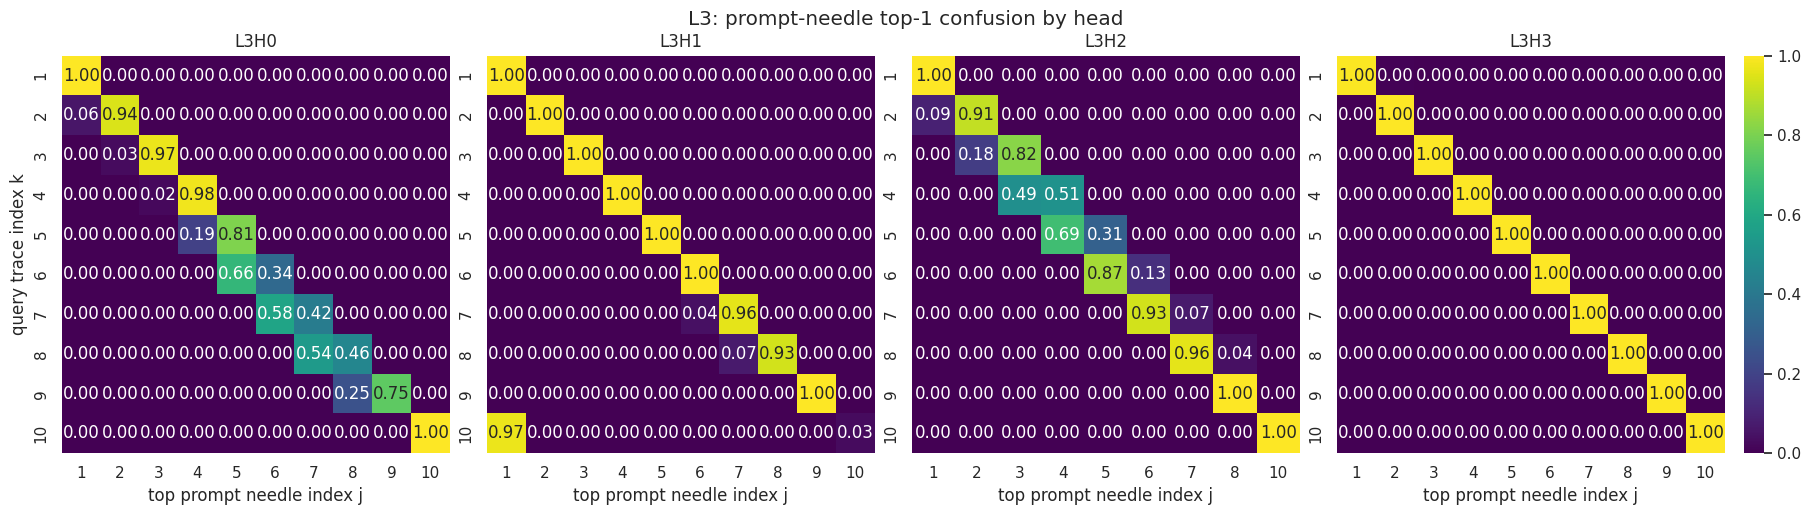

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.8), constrained_layout=True)
for head, ax in zip(range(4), axes):
    hdf = layer_focus[layer_focus["head"] == head]
    confusion = (
        hdf.groupby(["k", "top_prompt_needle_index"], as_index=False)
        .size()
        .assign(frac=lambda d: d.groupby("k")["size"].transform(lambda s: s / s.sum()))
    )
    mat = confusion.pivot(index="k", columns="top_prompt_needle_index", values="frac").fillna(0.0)
    sns.heatmap(mat, ax=ax, cmap="viridis", vmin=0, vmax=1, annot=True, fmt=".2f", cbar=(head == 3))
    ax.set_title(f"L{FOCUS_LAYER}H{head}")
    ax.set_xlabel("top prompt needle index j")
    ax.set_ylabel("query trace index k" if head == 0 else "")

fig.suptitle(f"L{FOCUS_LAYER}: prompt-needle top-1 confusion by head", y=1.04)
plt.savefig(FIG_DIR / f"thinking_L{FOCUS_LAYER}_needle_confusion_by_head.png", bbox_inches="tight", dpi=180)
plt.show()
        

## 9. 16-Head Total Attention Signatures

下面这张图是 16 个 heads 的总览。

- 横轴：token category。
- 纵轴：layer/head。
- 颜色：平均 attention mass。

这张图可以快速看出：哪些 head 是 BOS/self sink，哪些 head 看 prompt noise，哪些 head 看 prompt needles，哪些 head 看 previous trace token。
        

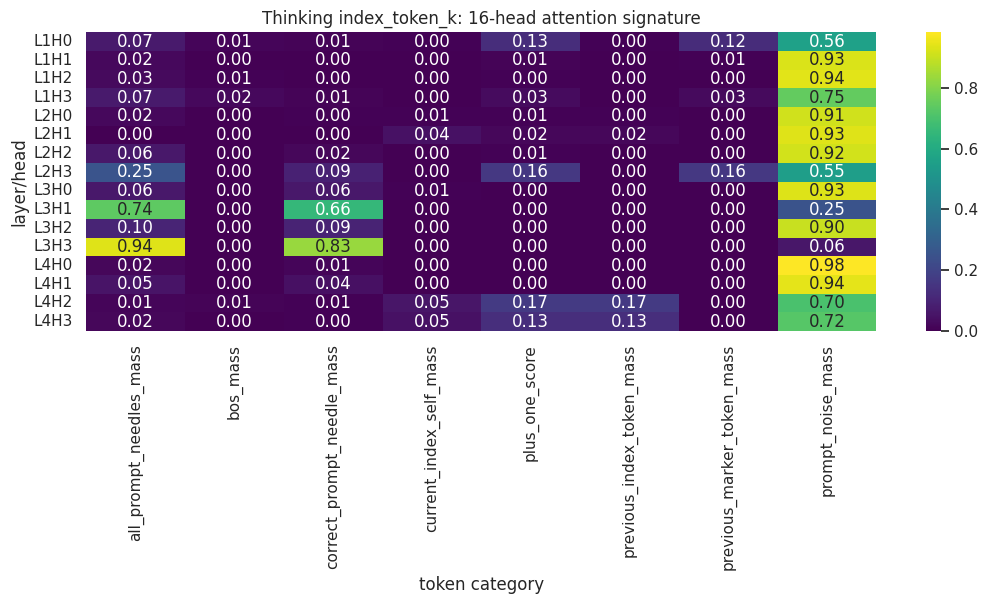

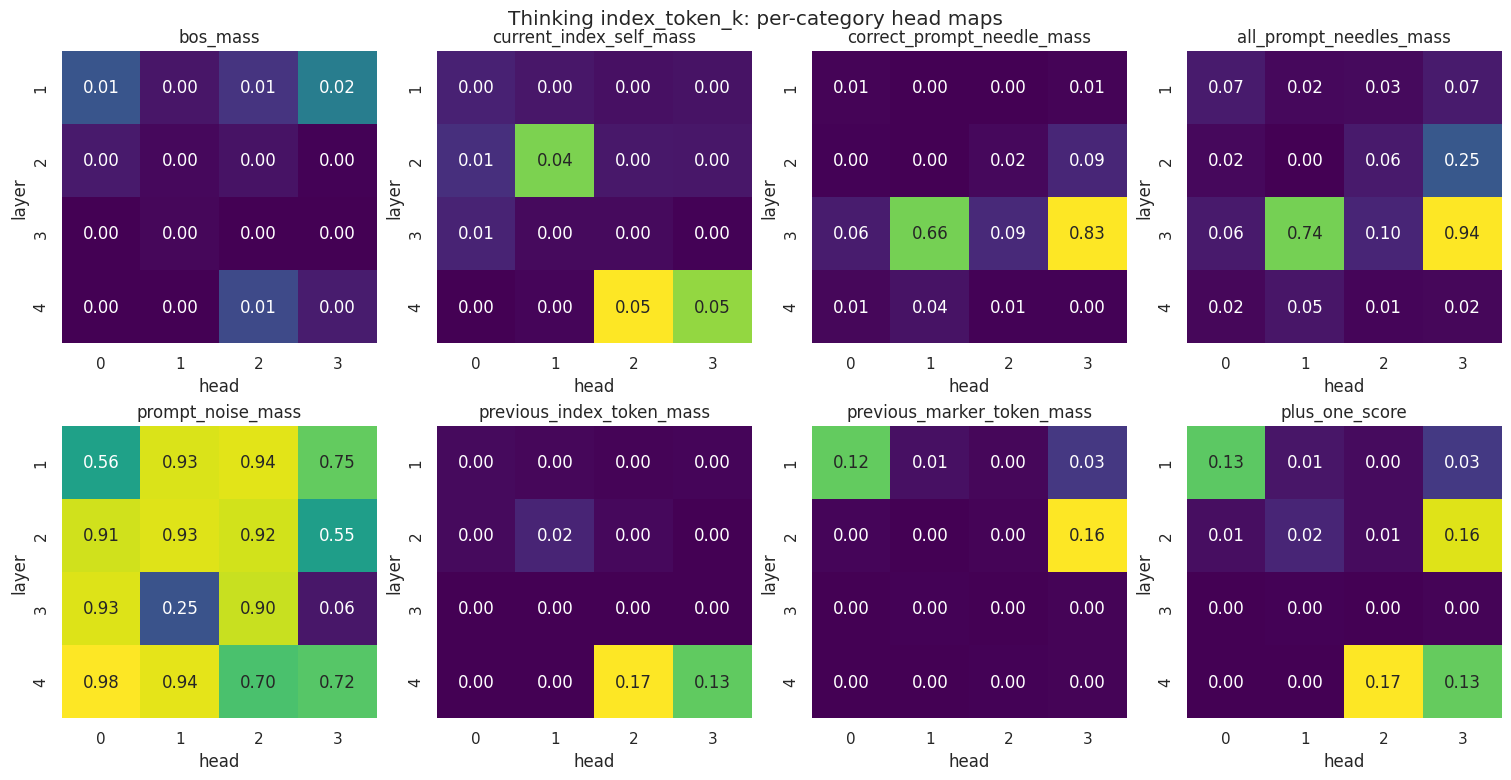

In [12]:
think_sig = think_head.copy()
think_sig["head_label"] = "L" + think_sig["layer"].astype(str) + "H" + think_sig["head"].astype(str)
sig_cols = [
    "bos_mass",
    "current_index_self_mass",
    "correct_prompt_needle_mass",
    "all_prompt_needles_mass",
    "prompt_noise_mass",
    "previous_index_token_mass",
    "previous_marker_token_mass",
    "plus_one_score",
]
think_sig_long = think_sig.melt(id_vars=["head_label"], value_vars=sig_cols, var_name="category", value_name="attention_mass")
think_pivot = think_sig_long.pivot(index="head_label", columns="category", values="attention_mass")
plt.figure(figsize=(11, 6.2))
sns.heatmap(think_pivot, cmap="viridis", annot=True, fmt=".2f", vmin=0, vmax=max(0.05, float(think_pivot.max().max())))
plt.title("Thinking index_token_k: 16-head attention signature")
plt.xlabel("token category")
plt.ylabel("layer/head")
plt.tight_layout()
plt.savefig(FIG_DIR / "thinking_16head_category_signature.png", bbox_inches="tight", dpi=180)
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(15, 7.5), constrained_layout=True)
for ax, metric in zip(axes.flat, sig_cols):
    mat = think_head.pivot(index="layer", columns="head", values=metric)
    sns.heatmap(mat, ax=ax, cmap="viridis", vmin=0, vmax=max(0.05, float(mat.max().max())), annot=True, fmt=".2f", cbar=False)
    ax.set_title(metric)
    ax.set_xlabel("head")
    ax.set_ylabel("layer")
plt.suptitle("Thinking index_token_k: per-category head maps", y=1.02)
plt.savefig(FIG_DIR / "thinking_16head_category_grid.png", bbox_inches="tight", dpi=180)
plt.show()
        

## 10. Automatic Interpretation Checkpoint

In [13]:
best_non_needles = non_head.sort_values("prompt_needles_mass", ascending=False).iloc[0]
best_non_noise = non_head.sort_values("prompt_noise_mass", ascending=False).iloc[0]
best_non_bos = non_head.sort_values("bos_mass", ascending=False).iloc[0]
best_think_retrieval = think_head.sort_values(["correct_top1_rate", "correct_prompt_needle_mass"], ascending=False).iloc[0]
l3_all = layer_summary[layer_summary["subset"] == "all_index_tokens"].sort_values("head").copy()
l3_last = layer_summary[layer_summary["subset"] == "last_index_only"].sort_values("head").copy()
l3h2_all = l3_all[l3_all["head"] == 2].iloc[0] if (l3_all["head"] == 2).any() else l3_all.iloc[0]
l3h2_last = l3_last[l3_last["head"] == 2].iloc[0] if (l3_last["head"] == 2).any() else l3_last.iloc[0]

def f3(x: float) -> str:
    return f"{float(x):.3f}"

def v(row: pd.Series, key: str):
    return row[key]

lines = []
lines.append("### v2.2 interpretation checkpoint")
lines.append("")
lines.append(
    f"- **Non-thinking:** best needle-mass head is L{int(v(best_non_needles, 'layer'))}H{int(v(best_non_needles, 'head'))} "
    f"with prompt_needles_mass={f3(v(best_non_needles, 'prompt_needles_mass'))} and normalized prompt entropy={f3(v(best_non_needles, 'prompt_entropy_normalized'))}."
)
lines.append(
    f"- **Non-thinking sink check:** max BOS mass is L{int(v(best_non_bos, 'layer'))}H{int(v(best_non_bos, 'head'))} "
    f"with bos_mass={f3(v(best_non_bos, 'bos_mass'))}; max prompt-noise mass is L{int(v(best_non_noise, 'layer'))}H{int(v(best_non_noise, 'head'))} "
    f"with prompt_noise_mass={f3(v(best_non_noise, 'prompt_noise_mass'))}."
)
lines.append(
    f"- **Thinking best retrieval:** L{int(v(best_think_retrieval, 'layer'))}H{int(v(best_think_retrieval, 'head'))} has "
    f"correct_top1={f3(v(best_think_retrieval, 'correct_top1_rate'))}, "
    f"diag_share={f3(v(best_think_retrieval, 'diag_share_of_needle_mass'))}, "
    f"correct_needle_mass={f3(v(best_think_retrieval, 'correct_prompt_needle_mass'))}."
)
lines.append("")
lines.append(f"#### Layer {FOCUS_LAYER} head comparison")
for _, row in l3_all.iterrows():
    lines.append(
        f"- **L{FOCUS_LAYER}H{int(v(row, 'head'))} all-k:** correct_top1={f3(v(row, 'correct_top1_rate'))}, "
        f"diag_share={f3(v(row, 'diag_share_of_needle_mass'))}, correct_needle_mass={f3(v(row, 'correct_prompt_needle_mass'))}, "
        f"all_needles_mass={f3(v(row, 'all_prompt_needles_mass'))}, BOS={f3(v(row, 'bos_mass'))}, "
        f"self={f3(v(row, 'current_index_self_mass'))}, noise={f3(v(row, 'prompt_noise_mass'))}, plus_one={f3(v(row, 'plus_one_score'))}."
    )
lines.append(
    f"- **L{FOCUS_LAYER}H2 last-index only:** correct_top1={f3(v(l3h2_last, 'correct_top1_rate'))}, "
    f"correct_needle_mass={f3(v(l3h2_last, 'correct_prompt_needle_mass'))}, "
    f"all_needles_mass={f3(v(l3h2_last, 'all_prompt_needles_mass'))}, BOS={f3(v(l3h2_last, 'bos_mass'))}, "
    f"self={f3(v(l3h2_last, 'current_index_self_mass'))}, plus_one={f3(v(l3h2_last, 'plus_one_score'))}."
)

if v(l3h2_all, "bos_mass") > 0.2:
    lines.append("- **L3H2 BOS note:** BOS mass is nontrivial, so BOS sink is part of this head's total attention story.")
else:
    lines.append("- **L3H2 BOS note:** BOS mass is not large enough to explain the low correct-top1 by itself.")

if v(l3h2_all, "correct_top1_rate") < 0.8 and v(l3h2_all, "diag_share_of_needle_mass") > 0.7:
    lines.append("- **Why high diagonal but lower retrieval?** The head can have high within-needle diagonal share on average while still losing top-1 on a sizable subset of queries; inspect the confusion matrix to see which k values go off-diagonal.")
elif v(l3h2_all, "correct_top1_rate") < 0.8:
    lines.append("- **Why lower retrieval?** L3H2 is not a clean targeted retrieval head under this metric; it either spreads to non-needle categories or chooses off-diagonal needles.")

display(Markdown("\n".join(lines)))
        

### v2.2 interpretation checkpoint

- **Non-thinking:** best needle-mass head is L1H2 with prompt_needles_mass=0.110 and normalized prompt entropy=0.981.
- **Non-thinking sink check:** max BOS mass is L4H3 with bos_mass=0.091; max prompt-noise mass is L2H3 with prompt_noise_mass=0.967.
- **Thinking best retrieval:** L3H3 has correct_top1=0.999, diag_share=0.887, correct_needle_mass=0.831.

#### Layer 3 head comparison
- **L3H0 all-k:** correct_top1=0.822, diag_share=0.792, correct_needle_mass=0.062, all_needles_mass=0.064, BOS=0.000, self=0.005, noise=0.931, plus_one=0.000.
- **L3H1 all-k:** correct_top1=0.975, diag_share=0.864, correct_needle_mass=0.656, all_needles_mass=0.739, BOS=0.001, self=0.001, noise=0.252, plus_one=0.001.
- **L3H2 all-k:** correct_top1=0.585, diag_share=0.591, correct_needle_mass=0.095, all_needles_mass=0.097, BOS=0.000, self=0.001, noise=0.901, plus_one=0.000.
- **L3H3 all-k:** correct_top1=0.999, diag_share=0.887, correct_needle_mass=0.831, all_needles_mass=0.936, BOS=0.000, self=0.000, noise=0.059, plus_one=0.001.
- **L3H2 last-index only:** correct_top1=0.292, correct_needle_mass=0.122, all_needles_mass=0.126, BOS=0.000, self=0.007, plus_one=0.001.
- **L3H2 BOS note:** BOS mass is not large enough to explain the low correct-top1 by itself.
- **Why lower retrieval?** L3H2 is not a clean targeted retrieval head under this metric; it either spreads to non-needle categories or chooses off-diagonal needles.

## 11. Mechanism Tests: Targeted Retrieval + Aggregate?

这一节补充三个不重训的机制实验，专门检验 CoT counting 是否更像 **targeted retrieval + aggregate/readout**：

1. **Final-answer readout attention**：在 thinking 模型的 `<Ans>` 位置，看 16 个 heads 是读 prompt needles、prompt noise，还是读已经生成的 trace tokens。
2. **Prompt-vs-trace conflict**：构造 prompt count 和 trace count 不一致的输入，问最终答案更跟 prompt 还是更跟 trace。
3. **Head-output ablation**：teacher-forced 地把候选 retrieval heads / broad heads 的 attention output 直接置零，看 trace marker 预测和 final answer 预测分别怎么变。

如果机制是 targeted retrieval + aggregate，我们预期：

- trace 中间步骤的 marker 预测强依赖 L3H3/L3H1 这类 targeted retrieval heads；
- final answer 更可能读 trace 或 broad aggregate features，而不是重新做一次 prompt targeted retrieval；
- broad attention head 不应简单按总 noise mass 判断，而要看 count-correlation、entropy、per-token enrichment 和 ablation。
        

In [14]:
RUN_THINKING_ANSWER_ATTENTION = True
RUN_PROMPT_TRACE_CONFLICT = True
RUN_HEAD_OUTPUT_ABLATION = True

MECHANISM_EXAMPLES_PER_COUNT = min(EXAMPLES_PER_COUNT, 50)
ABLATION_EXAMPLES_PER_COUNT = min(EXAMPLES_PER_COUNT, 10)
count_ids = [vocab.token_to_id[vocab.count_to_token(i)] for i in range(1, 11)]

ANSWER_CATEGORIES = [
    "bos_mass",
    "think_open_mass",
    "think_end_mass",
    "ans_self_mass",
    "prompt_needles_mass",
    "prompt_noise_mass",
    "trace_index_mass",
    "trace_marker_mass",
    "other_context_mass",
]

def pearson_safe(a, b) -> float:
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if len(a) < 2 or np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return float("nan")
    return float(np.corrcoef(a, b)[0, 1])

def collect_thinking_answer_attention(model, examples: list[BaseExample]) -> pd.DataFrame:
    rows = []
    model.eval()
    for ex_i, ex in enumerate(tqdm(examples, desc="thinking <Ans> attention")):
        r = render_thinking(ex, vocab)
        ids = torch.tensor([r["input_ids"]], device=DEVICE)
        with torch.no_grad():
            out = model(ids, output_attentions=True)
        q = r["anchors"]["ans_token"]
        prompt_positions = set(range(r["anchors"]["prompt_start"], r["anchors"]["prompt_end_exclusive"]))
        prompt_needles = set(r["anchors"]["prompt_needle_positions"])
        prompt_noise = prompt_positions - prompt_needles
        trace_indices = set(r["anchors"]["index_positions"])
        trace_markers = set(r["anchors"]["marker_positions"])
        trace_positions = trace_indices | trace_markers
        categories = [
            ("bos_mass", {0}),
            ("think_open_mass", {r["anchors"]["think_start"]}),
            ("think_end_mass", {r["anchors"]["think_end"]}),
            ("ans_self_mass", {q}),
            ("prompt_needles_mass", prompt_needles),
            ("prompt_noise_mass", prompt_noise),
            ("trace_index_mass", trace_indices),
            ("trace_marker_mass", trace_markers),
        ]
        for layer_idx, layer_attn in enumerate(out.attentions, start=1):
            for head in range(layer_attn.shape[1]):
                weights = layer_attn[0, head, q].detach().float().cpu().numpy()
                cats = disjoint_mass(weights, categories)
                top_pos = int(weights[: q + 1].argmax())
                prompt_weights = weights[sorted(prompt_positions)]
                trace_weights = weights[sorted(trace_positions)] if trace_positions else np.array([])
                rows.append({
                    "id": ex_i,
                    "count": ex.count,
                    "count_bin": count_bin(ex.count),
                    "layer": layer_idx,
                    "head": head,
                    "top_position": top_pos,
                    "top_token": r["tokens"][top_pos],
                    "top_role": token_role(top_pos, r, ex),
                    "prompt_entropy_normalized": attention_entropy(prompt_weights) / math.log(len(prompt_weights)),
                    "trace_entropy_normalized": attention_entropy(trace_weights) / math.log(len(trace_weights)) if len(trace_weights) > 1 else 0.0,
                    "needle_per_token_mass": mass(weights, prompt_needles) / max(len(prompt_needles), 1),
                    "noise_per_token_mass": mass(weights, prompt_noise) / max(len(prompt_noise), 1),
                    "trace_index_per_token_mass": mass(weights, trace_indices) / max(len(trace_indices), 1),
                    "trace_marker_per_token_mass": mass(weights, trace_markers) / max(len(trace_markers), 1),
                    **cats,
                })
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return pd.DataFrame(rows)

ans_path = TABLE_DIR / "thinking_answer_attention_rows.csv"
answer_examples = balanced_examples(int(cfg["seq_len"]), MECHANISM_EXAMPLES_PER_COUNT, RANDOM_SEED + 3301)
if RUN_THINKING_ANSWER_ATTENTION:
    if REUSE_EXISTING_TABLES and ans_path.exists():
        ans_df = pd.read_csv(ans_path)
    else:
        ans_df = collect_thinking_answer_attention(think_model, answer_examples)
        ans_df.to_csv(ans_path, index=False)
else:
    ans_df = pd.read_csv(ans_path)

summary_rows = []
for (layer, head), g in ans_df.groupby(["layer", "head"]):
    prompt_mass = g["prompt_needles_mass"] + g["prompt_noise_mass"]
    trace_mass = g["trace_index_mass"] + g["trace_marker_mass"]
    row = {
        "layer": int(layer),
        "head": int(head),
        "n_examples": len(g),
        "prompt_mass": float(prompt_mass.mean()),
        "prompt_needles_mass": float(g["prompt_needles_mass"].mean()),
        "prompt_noise_mass": float(g["prompt_noise_mass"].mean()),
        "trace_mass": float(trace_mass.mean()),
        "trace_index_mass": float(g["trace_index_mass"].mean()),
        "trace_marker_mass": float(g["trace_marker_mass"].mean()),
        "bos_mass": float(g["bos_mass"].mean()),
        "think_open_mass": float(g["think_open_mass"].mean()),
        "think_end_mass": float(g["think_end_mass"].mean()),
        "ans_self_mass": float(g["ans_self_mass"].mean()),
        "other_context_mass": float(g["other_context_mass"].mean()),
        "prompt_entropy_normalized": float(g["prompt_entropy_normalized"].mean()),
        "trace_entropy_normalized": float(g["trace_entropy_normalized"].mean()),
        "needle_per_token_mass": float(g["needle_per_token_mass"].mean()),
        "noise_per_token_mass": float(g["noise_per_token_mass"].mean()),
        "needle_enrichment": float(g["needle_per_token_mass"].mean() / max(g["noise_per_token_mass"].mean(), 1e-12)),
        "corr_count_prompt_needles_mass": pearson_safe(g["count"], g["prompt_needles_mass"]),
        "corr_count_trace_index_mass": pearson_safe(g["count"], g["trace_index_mass"]),
        "corr_count_trace_marker_mass": pearson_safe(g["count"], g["trace_marker_mass"]),
        "corr_count_prompt_mass": pearson_safe(g["count"], prompt_mass),
        "corr_count_trace_mass": pearson_safe(g["count"], trace_mass),
    }
    row["broad_prompt_aggregate_score"] = row["prompt_mass"] * row["prompt_entropy_normalized"] * abs(row["corr_count_prompt_needles_mass"] if not math.isnan(row["corr_count_prompt_needles_mass"]) else 0.0)
    row["trace_readout_score"] = row["trace_mass"] * abs(row["corr_count_trace_mass"] if not math.isnan(row["corr_count_trace_mass"]) else 0.0)
    summary_rows.append(row)

ans_head = pd.DataFrame(summary_rows)
ans_head.to_csv(TABLE_DIR / "thinking_answer_head_summary.csv", index=False)

display(Markdown(f"Saved: `{ans_path}`"))
display(Markdown("**Top final-answer heads by broad prompt aggregate score.**"))
display(ans_head.sort_values("broad_prompt_aggregate_score", ascending=False).head(8))
display(Markdown("**Top final-answer heads by trace readout score.**"))
display(ans_head.sort_values("trace_readout_score", ascending=False).head(8))
        

Saved: `/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results/v2_marker_trace_main_seed1234_20260706_215757/run/v2_2_attention_diagnostics/tables/thinking_answer_attention_rows.csv`

**Top final-answer heads by broad prompt aggregate score.**

,layer,head,n_examples,prompt_mass,prompt_needles_mass,prompt_noise_mass,trace_mass,trace_index_mass,trace_marker_mass,bos_mass,think_open_mass,think_end_mass,ans_self_mass,other_context_mass,prompt_entropy_normalized,trace_entropy_normalized,needle_per_token_mass,noise_per_token_mass,needle_enrichment,corr_count_prompt_needles_mass,corr_count_trace_index_mass,corr_count_trace_marker_mass,corr_count_prompt_mass,corr_count_trace_mass,broad_prompt_aggregate_score,trace_readout_score
1,1,1,500,0.933926,0.026284,0.907642,0.046729,0.023460,0.023269,0.005158,0.005165,0.004959,0.004063,2.162810e-08,0.998867,0.996414,0.005142,0.003622,1.419516,0.919405,0.995686,0.844601,-0.902916,0.934264,0.857684,0.043657
2,1,2,500,0.914618,0.035319,0.879298,0.058873,0.027010,0.031863,0.011750,0.005331,0.004980,0.004448,2.264883e-08,0.997733,0.997554,0.007413,0.003509,2.112712,0.815825,0.968157,0.861532,-0.752331,0.912502,0.744476,0.053722
4,2,0,500,0.906474,0.033431,0.873044,0.069948,0.021374,0.048574,0.003881,0.007496,0.004752,0.007448,2.353382e-08,0.982246,0.952284,0.004744,0.003481,1.362831,0.783975,0.926742,0.761272,-0.810445,0.801744,0.698037,0.056081
3,1,3,500,0.928779,0.033143,0.895636,0.051021,0.022247,0.028774,0.007253,0.005374,0.004416,0.003157,2.202182e-08,0.997038,0.990762,0.006282,0.003574,1.757959,0.657321,0.901298,0.670230,-0.670883,0.749417,0.608697,0.038236
0,1,0,500,0.914082,0.036178,0.877904,0.061611,0.023250,0.038361,0.009163,0.004516,0.004312,0.006316,2.043601e-08,0.997276,0.951152,0.008863,0.003504,2.529091,0.650980,0.963544,0.241545,-0.298549,0.617203,0.593428,0.038026
13,4,1,500,0.603204,0.036915,0.566290,0.189143,0.015542,0.173601,0.016527,0.039128,0.097797,0.054199,2.118069e-08,0.843784,0.681689,0.004447,0.002264,1.964538,0.737215,0.356103,0.598958,0.462478,0.605947,0.375223,0.114611
9,3,1,500,0.915668,0.028929,0.886739,0.031717,0.009630,0.022087,0.051621,0.000337,0.000140,0.000518,2.196587e-08,0.717029,0.322315,0.004601,0.003537,1.300731,0.529288,0.588260,0.619513,-0.602414,0.618970,0.347510,0.019632
8,3,0,500,0.970621,0.086350,0.884271,0.011812,0.003596,0.008216,0.017484,0.000075,0.000003,0.000005,2.612896e-08,0.705479,0.247640,0.012435,0.003525,3.527982,0.498303,0.486661,0.451786,-0.568707,0.467608,0.341214,0.005523


**Top final-answer heads by trace readout score.**

,layer,head,n_examples,prompt_mass,prompt_needles_mass,prompt_noise_mass,trace_mass,trace_index_mass,trace_marker_mass,bos_mass,think_open_mass,think_end_mass,ans_self_mass,other_context_mass,prompt_entropy_normalized,trace_entropy_normalized,needle_per_token_mass,noise_per_token_mass,needle_enrichment,corr_count_prompt_needles_mass,corr_count_trace_index_mass,corr_count_trace_marker_mass,corr_count_prompt_mass,corr_count_trace_mass,broad_prompt_aggregate_score,trace_readout_score
14,4,2,500,0.554934,0.049144,0.505791,0.330888,0.066058,0.264830,0.009164,0.022379,0.033276,0.049359,2.121331e-08,0.838367,0.525499,0.008385,0.002013,4.165027,0.389475,-0.269768,0.678171,-0.505626,0.675683,0.181199,0.223575
7,2,3,500,0.456463,0.158137,0.298326,0.268227,0.013588,0.254639,0.001261,0.231214,0.003029,0.039807,2.167205e-08,0.750578,0.644996,0.024251,0.001192,20.337012,0.790348,0.907867,0.633634,0.634354,0.671227,0.270782,0.180041
13,4,1,500,0.603204,0.036915,0.566290,0.189143,0.015542,0.173601,0.016527,0.039128,0.097797,0.054199,2.118069e-08,0.843784,0.681689,0.004447,0.002264,1.964538,0.737215,0.356103,0.598958,0.462478,0.605947,0.375223,0.114611
6,2,2,500,0.796401,0.290832,0.505568,0.180392,0.012750,0.167642,0.001716,0.004856,0.003002,0.013633,2.189795e-08,0.625682,0.642726,0.067930,0.002018,33.668367,-0.125199,0.807074,0.241607,-0.514745,0.352851,0.062386,0.063652
4,2,0,500,0.906474,0.033431,0.873044,0.069948,0.021374,0.048574,0.003881,0.007496,0.004752,0.007448,2.353382e-08,0.982246,0.952284,0.004744,0.003481,1.362831,0.783975,0.926742,0.761272,-0.810445,0.801744,0.698037,0.056081
2,1,2,500,0.914618,0.035319,0.879298,0.058873,0.027010,0.031863,0.011750,0.005331,0.004980,0.004448,2.264883e-08,0.997733,0.997554,0.007413,0.003509,2.112712,0.815825,0.968157,0.861532,-0.752331,0.912502,0.744476,0.053722
1,1,1,500,0.933926,0.026284,0.907642,0.046729,0.023460,0.023269,0.005158,0.005165,0.004959,0.004063,2.162810e-08,0.998867,0.996414,0.005142,0.003622,1.419516,0.919405,0.995686,0.844601,-0.902916,0.934264,0.857684,0.043657
3,1,3,500,0.928779,0.033143,0.895636,0.051021,0.022247,0.028774,0.007253,0.005374,0.004416,0.003157,2.202182e-08,0.997038,0.990762,0.006282,0.003574,1.757959,0.657321,0.901298,0.670230,-0.670883,0.749417,0.608697,0.038236


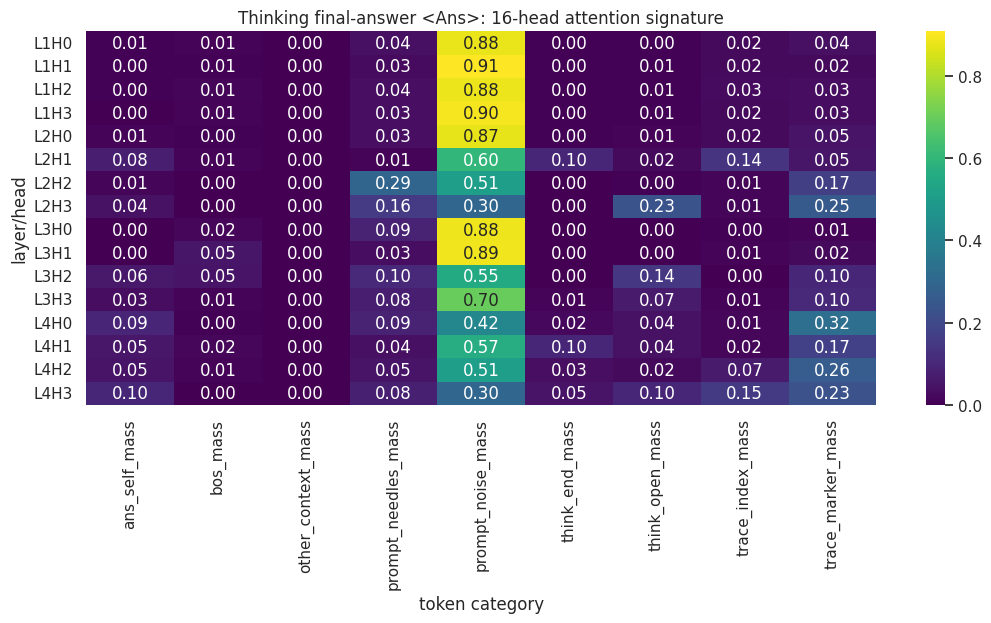

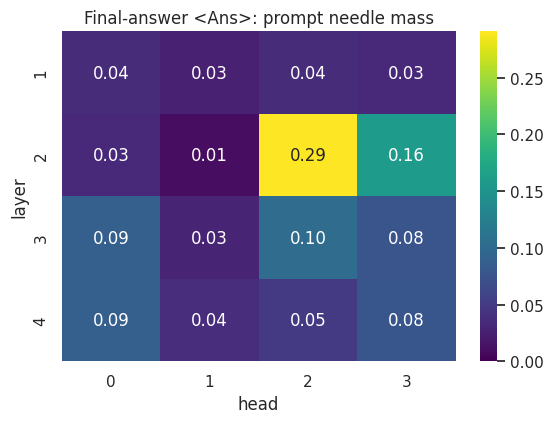

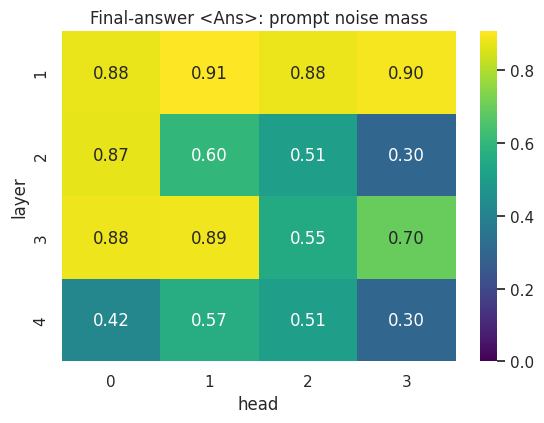

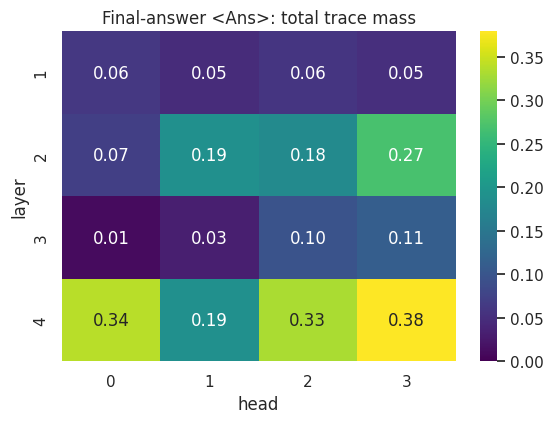

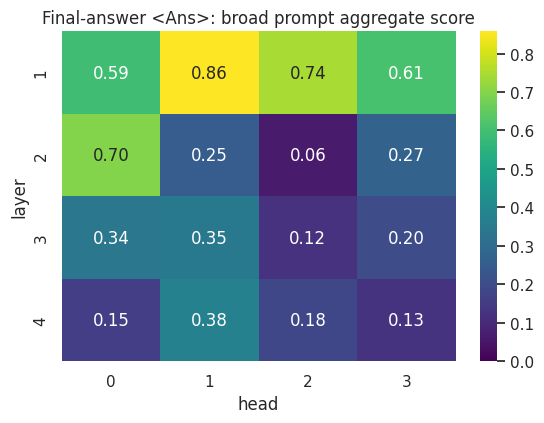

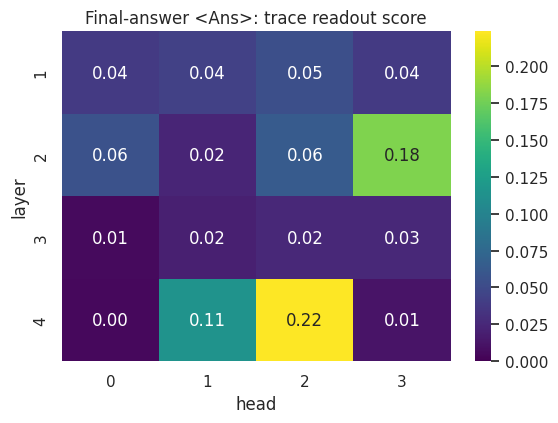

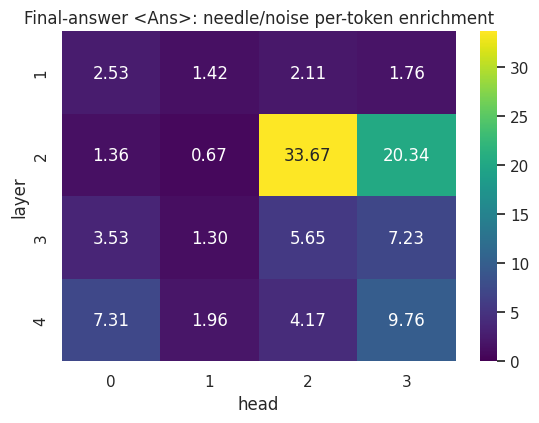

In [15]:
ans_sig = ans_head.copy()
ans_sig["head_label"] = "L" + ans_sig["layer"].astype(str) + "H" + ans_sig["head"].astype(str)
for col in ANSWER_CATEGORIES:
    if col not in ans_sig.columns:
        ans_sig[col] = 0.0
ans_sig_long = ans_sig.melt(id_vars=["head_label"], value_vars=ANSWER_CATEGORIES, var_name="category", value_name="attention_mass")
ans_pivot = ans_sig_long.pivot(index="head_label", columns="category", values="attention_mass")
plt.figure(figsize=(11, 6.4))
sns.heatmap(ans_pivot, cmap="viridis", annot=True, fmt=".2f", vmin=0, vmax=max(0.05, float(ans_pivot.max().max())))
plt.title("Thinking final-answer <Ans>: 16-head attention signature")
plt.xlabel("token category")
plt.ylabel("layer/head")
plt.tight_layout()
plt.savefig(FIG_DIR / "thinking_answer_16head_category_signature.png", bbox_inches="tight", dpi=180)
plt.show()

for metric, title, fname, vmax in [
    ("prompt_needles_mass", "Final-answer <Ans>: prompt needle mass", "thinking_answer_prompt_needles_mass_by_head.png", None),
    ("prompt_noise_mass", "Final-answer <Ans>: prompt noise mass", "thinking_answer_prompt_noise_mass_by_head.png", None),
    ("trace_mass", "Final-answer <Ans>: total trace mass", "thinking_answer_trace_mass_by_head.png", None),
    ("broad_prompt_aggregate_score", "Final-answer <Ans>: broad prompt aggregate score", "thinking_answer_broad_prompt_score_by_head.png", None),
    ("trace_readout_score", "Final-answer <Ans>: trace readout score", "thinking_answer_trace_readout_score_by_head.png", None),
    ("needle_enrichment", "Final-answer <Ans>: needle/noise per-token enrichment", "thinking_answer_needle_enrichment_by_head.png", None),
]:
    heatmap_layer_head(ans_head, metric, title, fname, vmin=0.0, vmax=vmax)
        

### 11.1 Prompt-vs-Trace Conflict Test

这个实验把 prompt 和 trace 故意做成不一致：

- `prompt_minus1_trace_clean`：prompt 删除最后一个 needle，prompt count 变成 `n-1`，但 teacher-forced trace 仍然保留 `n` 个计数步骤。
- `prompt_clean_trace_minus1`：prompt 保持 `n` 个 needle，但 trace 截断为 `n-1` 个计数步骤。

在 `<Ans>` 位置比较两个候选 count token 的 logit：如果模型更依赖 prompt，应该跟 prompt count；如果更依赖 trace aggregate/readout，应该跟 trace count。
        

,condition,n,trace_follow_rate,prompt_follow_rate,other_rate,trace_wins_logit_rate,mean_trace_minus_prompt_logit
0,prompt_clean_trace_minus1,450,1.0,0.0,0.0,1.0,14.807639
1,prompt_minus1_trace_clean,450,1.0,0.0,0.0,1.0,16.119220


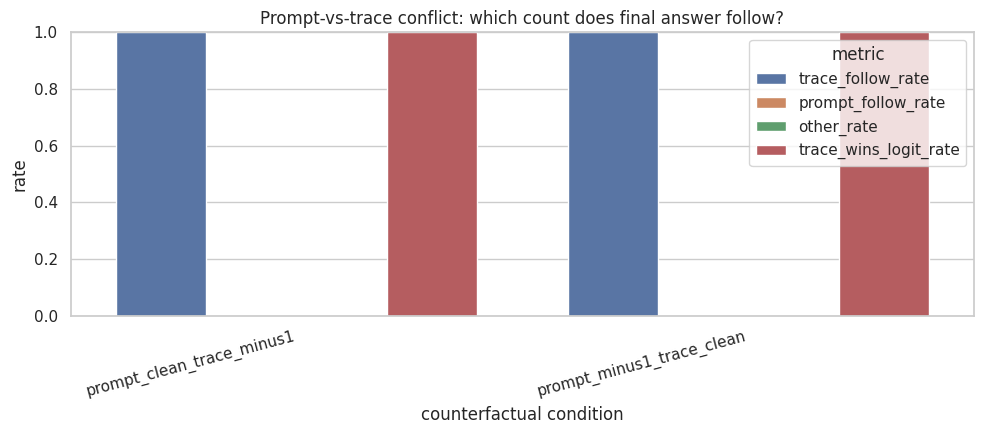

In [16]:
def render_thinking_mismatch(ex: BaseExample, prompt_count: int, trace_count: int) -> dict[str, Any]:
    seq = list(ex.seq_tokens)
    # Replace removed prompt needles by deterministic noise while keeping length fixed.
    for pos in ex.needle_positions[prompt_count:]:
        seq[pos] = NOISE_TOKENS[(pos + prompt_count * 17 + trace_count * 31) % len(NOISE_TOKENS)]
    trace = []
    for idx, pos in enumerate(ex.needle_positions[:trace_count], start=1):
        trace.extend([vocab.count_to_token(idx), ex.seq_tokens[pos]])
    tokens = ["<BOS>"] + seq + ["<Think/>"] + trace + ["</Think>", "<Ans>"]
    return {
        "tokens": tokens,
        "input_ids": vocab.encode(tokens),
        "anchors": {"ans_token": len(tokens) - 1},
        "prompt_count": prompt_count,
        "trace_count": trace_count,
    }

@torch.no_grad()
def answer_count_logits(model, rendered: dict[str, Any]) -> torch.Tensor:
    ids = torch.tensor([rendered["input_ids"]], device=DEVICE)
    logits = model(ids).logits[0, rendered["anchors"]["ans_token"]]
    return logits.detach().float().cpu()

conflict_path = TABLE_DIR / "thinking_answer_prompt_trace_conflict.csv"
conflict_examples = [ex for ex in balanced_examples(int(cfg["seq_len"]), MECHANISM_EXAMPLES_PER_COUNT, RANDOM_SEED + 3302) if ex.count >= 2]

if RUN_PROMPT_TRACE_CONFLICT:
    if REUSE_EXISTING_TABLES and conflict_path.exists():
        conflict_df = pd.read_csv(conflict_path)
    else:
        rows = []
        think_model.eval()
        for ex_i, ex in enumerate(tqdm(conflict_examples, desc="prompt-vs-trace conflicts")):
            settings = [
                ("prompt_minus1_trace_clean", ex.count - 1, ex.count),
                ("prompt_clean_trace_minus1", ex.count, ex.count - 1),
            ]
            for condition, prompt_count, trace_count in settings:
                r = render_thinking_mismatch(ex, prompt_count=prompt_count, trace_count=trace_count)
                logits = answer_count_logits(think_model, r)
                count_logits = logits[count_ids]
                pred_count = int(count_logits.argmax().item()) + 1
                prompt_id = vocab.token_to_id[vocab.count_to_token(prompt_count)]
                trace_id = vocab.token_to_id[vocab.count_to_token(trace_count)]
                prompt_logit = float(logits[prompt_id].item())
                trace_logit = float(logits[trace_id].item())
                if pred_count == trace_count:
                    follows = "trace"
                elif pred_count == prompt_count:
                    follows = "prompt"
                else:
                    follows = "other"
                rows.append({
                    "id": ex_i,
                    "original_count": ex.count,
                    "condition": condition,
                    "prompt_count": prompt_count,
                    "trace_count": trace_count,
                    "pred_count": pred_count,
                    "follows": follows,
                    "prompt_logit": prompt_logit,
                    "trace_logit": trace_logit,
                    "trace_minus_prompt_logit": trace_logit - prompt_logit,
                    "trace_wins_logit": float(trace_logit > prompt_logit),
                    "prompt_wins_logit": float(prompt_logit > trace_logit),
                })
        conflict_df = pd.DataFrame(rows)
        conflict_df.to_csv(conflict_path, index=False)
else:
    conflict_df = pd.read_csv(conflict_path)

conflict_summary = (
    conflict_df.groupby("condition", as_index=False)
    .agg(
        n=("id", "size"),
        trace_follow_rate=("follows", lambda s: float((s == "trace").mean())),
        prompt_follow_rate=("follows", lambda s: float((s == "prompt").mean())),
        other_rate=("follows", lambda s: float((s == "other").mean())),
        trace_wins_logit_rate=("trace_wins_logit", "mean"),
        mean_trace_minus_prompt_logit=("trace_minus_prompt_logit", "mean"),
    )
)
conflict_summary.to_csv(TABLE_DIR / "thinking_answer_prompt_trace_conflict_summary.csv", index=False)
display(conflict_summary)

plot_df = conflict_summary.melt(
    id_vars=["condition"],
    value_vars=["trace_follow_rate", "prompt_follow_rate", "other_rate", "trace_wins_logit_rate"],
    var_name="metric",
    value_name="rate",
)
plt.figure(figsize=(10, 4.5))
sns.barplot(data=plot_df, x="condition", y="rate", hue="metric")
plt.title("Prompt-vs-trace conflict: which count does final answer follow?")
plt.xlabel("counterfactual condition")
plt.ylabel("rate")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "thinking_answer_prompt_trace_conflict.png", bbox_inches="tight", dpi=180)
plt.show()
        

### 11.2 Head-Output Ablation

这个实验用 `c_proj` pre-hook 在 teacher-forced forward 中直接置零指定 head 的 attention output slice，比较两个输出：

- `trace_marker_acc` / `trace_marker_margin`：在每个 trace index token `<k>` 后预测对应 marker 的准确率/边际。这个测试 targeted retrieval 是否必要。
- `answer_acc` / `answer_count_margin`：在 `<Ans>` 后预测最终 count 的准确率/边际。这个测试 final readout 是否依赖某些 broad/trace heads。

注意：这是 teacher-forced ablation。它不模拟 autoregressive 中前面 trace 生成错误的连锁效应，因此更适合看局部因果贡献。
        

,condition,mask_heads,n_examples,n_marker_queries,answer_acc,answer_count_margin,trace_marker_acc,trace_marker_margin
0,none,none,100,550,1.00,17.608605,1.000000,15.490540
1,mask_L3H3_main_retrieval,L3H3,100,550,1.00,14.861807,1.000000,12.281255
2,mask_L3H1_aux_retrieval,L3H1,100,550,1.00,17.604871,1.000000,15.381382
3,mask_L3H1_H3_retrieval,"L3H1,L3H3",100,550,1.00,14.837292,0.994545,10.529357
4,mask_L3H0_broad_noise,L3H0,100,550,1.00,17.474167,1.000000,15.357950
5,mask_L3H2_lag_noise,L3H2,100,550,1.00,16.866039,1.000000,15.218223
6,mask_L3_all,"L3H0,L3H1,L3H2,L3H3",100,550,1.00,12.674986,0.614545,1.634744
7,mask_layer1_all,"L1H0,L1H1,L1H2,L1H3",100,550,0.30,-1.377472,0.158182,-3.038268
8,mask_layer2_all,"L2H0,L2H1,L2H2,L2H3",100,550,0.56,2.254641,0.661818,4.475249
9,mask_layer3_all,"L3H0,L3H1,L3H2,L3H3",100,550,1.00,12.674986,0.614545,1.634744


**Ablation deltas relative to no mask.**

,condition,mask_heads,delta_answer_acc,delta_answer_count_margin,delta_trace_marker_acc,delta_trace_marker_margin
0,none,none,0.00,0.000000,0.000000,0.000000
1,mask_L3H3_main_retrieval,L3H3,0.00,-2.746799,0.000000,-3.209286
2,mask_L3H1_aux_retrieval,L3H1,0.00,-0.003734,0.000000,-0.109159
3,mask_L3H1_H3_retrieval,"L3H1,L3H3",0.00,-2.771313,-0.005455,-4.961183
4,mask_L3H0_broad_noise,L3H0,0.00,-0.134438,0.000000,-0.132590
5,mask_L3H2_lag_noise,L3H2,0.00,-0.742566,0.000000,-0.272318
6,mask_L3_all,"L3H0,L3H1,L3H2,L3H3",0.00,-4.933619,-0.385455,-13.855797
7,mask_layer1_all,"L1H0,L1H1,L1H2,L1H3",-0.70,-18.986077,-0.841818,-18.528808
8,mask_layer2_all,"L2H0,L2H1,L2H2,L2H3",-0.44,-15.353964,-0.338182,-11.015291
9,mask_layer3_all,"L3H0,L3H1,L3H2,L3H3",0.00,-4.933619,-0.385455,-13.855797


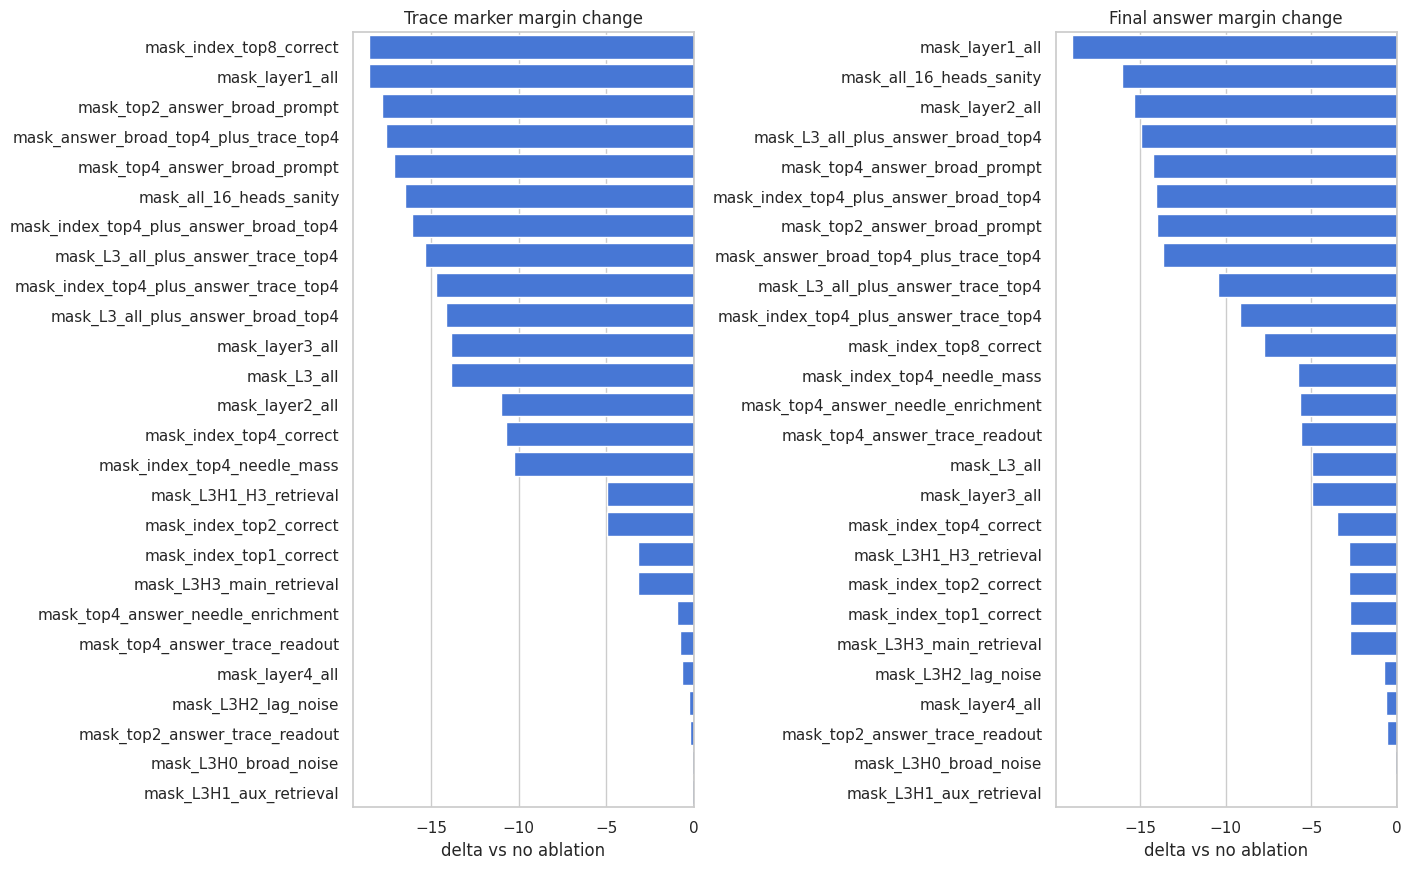

In [17]:
@contextmanager
def ablate_gpt2_attention_heads(model: GPT2LMHeadModel, mask_heads: list[tuple[int, int]]):
    # Zero selected per-head attention outputs before each layer's c_proj.
    handles = []
    by_layer: dict[int, list[int]] = {}
    for layer_1based, head in mask_heads:
        by_layer.setdefault(int(layer_1based), []).append(int(head))

    head_dim = int(model.config.n_embd) // int(model.config.n_head)
    for layer_1based, heads in by_layer.items():
        attn = model.transformer.h[layer_1based - 1].attn
        spans = [(h * head_dim, (h + 1) * head_dim) for h in heads]

        def pre_hook(module, inputs, spans=spans):
            x = inputs[0].clone()
            for start, stop in spans:
                x[..., start:stop] = 0.0
            return (x,) + tuple(inputs[1:])

        handles.append(attn.c_proj.register_forward_pre_hook(pre_hook))
    try:
        yield
    finally:
        for handle in handles:
            handle.remove()

@torch.no_grad()
def eval_marker_and_answer_with_ablation(model, examples: list[BaseExample], condition: str, mask_heads: list[tuple[int, int]]) -> dict[str, float]:
    marker_ids = [vocab.token_to_id[t] for t in MARKER_TOKENS]
    answer_correct = []
    answer_margins = []
    marker_correct = []
    marker_margins = []
    model.eval()
    for ex in tqdm(examples, desc=f"head output ablation {condition}", leave=False):
        r = render_thinking(ex, vocab)
        ids = torch.tensor([r["input_ids"]], device=DEVICE)
        attention_mask = torch.ones_like(ids)
        with ablate_gpt2_attention_heads(model, mask_heads):
            out = model(input_ids=ids, attention_mask=attention_mask, use_cache=False)
        logits = out.logits[0]
        ans_logits = logits[r["anchors"]["ans_token"]]
        gold_count_id = vocab.token_to_id[vocab.count_to_token(ex.count)]
        count_logits = ans_logits[count_ids]
        pred_count_id = count_ids[int(count_logits.argmax().item())]
        other_count_ids = [cid for cid in count_ids if cid != gold_count_id]
        answer_correct.append(float(pred_count_id == gold_count_id))
        answer_margins.append(float(ans_logits[gold_count_id].item() - ans_logits[other_count_ids].max().item()))

        for idx, index_pos in enumerate(r["anchors"]["index_positions"]):
            gold_marker = ex.seq_tokens[ex.needle_positions[idx]]
            gold_marker_id = vocab.token_to_id[gold_marker]
            marker_logits = logits[index_pos]
            pred_marker_id = marker_ids[int(marker_logits[marker_ids].argmax().item())]
            other_marker_ids = [mid for mid in marker_ids if mid != gold_marker_id]
            marker_correct.append(float(pred_marker_id == gold_marker_id))
            marker_margins.append(float(marker_logits[gold_marker_id].item() - marker_logits[other_marker_ids].max().item()))

    return {
        "condition": condition,
        "mask_heads": ",".join([f"L{l}H{h}" for l, h in mask_heads]) or "none",
        "n_examples": len(examples),
        "n_marker_queries": len(marker_correct),
        "answer_acc": float(np.mean(answer_correct)),
        "answer_count_margin": float(np.mean(answer_margins)),
        "trace_marker_acc": float(np.mean(marker_correct)),
        "trace_marker_margin": float(np.mean(marker_margins)),
    }

ablation_path = TABLE_DIR / "thinking_head_output_multi_ablation.csv"
ablation_examples = balanced_examples(int(cfg["seq_len"]), ABLATION_EXAMPLES_PER_COUNT, RANDOM_SEED + 3303)

if RUN_HEAD_OUTPUT_ABLATION:
    if REUSE_EXISTING_TABLES and ablation_path.exists():
        ablation_df = pd.read_csv(ablation_path)
    else:
        n_layer = int(think_model.config.n_layer)
        n_head = int(think_model.config.n_head)

        def unique_heads(heads: list[tuple[int, int]]) -> list[tuple[int, int]]:
            out = []
            seen = set()
            for layer, head in heads:
                item = (int(layer), int(head))
                if item not in seen:
                    out.append(item)
                    seen.add(item)
            return out

        def top_heads(df: pd.DataFrame, score: str, k: int) -> list[tuple[int, int]]:
            if score not in df.columns:
                return []
            rows = df.sort_values(score, ascending=False)[["layer", "head"]].head(k).itertuples(index=False, name=None)
            return unique_heads([(int(l), int(h)) for l, h in rows])

        def layer_heads(layer: int) -> list[tuple[int, int]]:
            return [(int(layer), h) for h in range(n_head)]

        index_top1 = top_heads(think_head, "correct_top1_rate", 1)
        index_top2 = top_heads(think_head, "correct_top1_rate", 2)
        index_top4 = top_heads(think_head, "correct_top1_rate", 4)
        index_top8 = top_heads(think_head, "correct_top1_rate", 8)
        index_mass_top4 = top_heads(think_head, "all_prompt_needles_mass", 4)
        answer_broad_top2 = top_heads(ans_head, "broad_prompt_aggregate_score", 2)
        answer_broad_top4 = top_heads(ans_head, "broad_prompt_aggregate_score", 4)
        answer_trace_top2 = top_heads(ans_head, "trace_readout_score", 2)
        answer_trace_top4 = top_heads(ans_head, "trace_readout_score", 4)
        answer_enrich_top4 = top_heads(ans_head, "needle_enrichment", 4)

        mask_conditions = [
            ("none", []),
            ("mask_L3H3_main_retrieval", [(3, 3)]),
            ("mask_L3H1_aux_retrieval", [(3, 1)]),
            ("mask_L3H1_H3_retrieval", [(3, 1), (3, 3)]),
            ("mask_L3H0_broad_noise", [(3, 0)]),
            ("mask_L3H2_lag_noise", [(3, 2)]),
            ("mask_L3_all", [(3, 0), (3, 1), (3, 2), (3, 3)]),
            ("mask_layer1_all", layer_heads(1)),
            ("mask_layer2_all", layer_heads(2)),
            ("mask_layer3_all", layer_heads(3)),
            ("mask_layer4_all", layer_heads(4)),
            ("mask_index_top1_correct", index_top1),
            ("mask_index_top2_correct", index_top2),
            ("mask_index_top4_correct", index_top4),
            ("mask_index_top8_correct", index_top8),
            ("mask_index_top4_needle_mass", index_mass_top4),
            ("mask_top2_answer_broad_prompt", answer_broad_top2),
            ("mask_top4_answer_broad_prompt", answer_broad_top4),
            ("mask_top2_answer_trace_readout", answer_trace_top2),
            ("mask_top4_answer_trace_readout", answer_trace_top4),
            ("mask_top4_answer_needle_enrichment", answer_enrich_top4),
            ("mask_index_top4_plus_answer_trace_top4", unique_heads(index_top4 + answer_trace_top4)),
            ("mask_index_top4_plus_answer_broad_top4", unique_heads(index_top4 + answer_broad_top4)),
            ("mask_answer_broad_top4_plus_trace_top4", unique_heads(answer_broad_top4 + answer_trace_top4)),
            ("mask_L3_all_plus_answer_trace_top4", unique_heads(layer_heads(3) + answer_trace_top4)),
            ("mask_L3_all_plus_answer_broad_top4", unique_heads(layer_heads(3) + answer_broad_top4)),
            ("mask_all_16_heads_sanity", [(l, h) for l in range(1, n_layer + 1) for h in range(n_head)]),
        ]
        rows = [eval_marker_and_answer_with_ablation(think_model, ablation_examples, name, heads) for name, heads in mask_conditions]
        ablation_df = pd.DataFrame(rows)
        ablation_df.to_csv(ablation_path, index=False)
else:
    ablation_df = pd.read_csv(ablation_path)

display(ablation_df)

base = ablation_df[ablation_df["condition"] == "none"].iloc[0]
delta = ablation_df.copy()
for col in ["answer_acc", "answer_count_margin", "trace_marker_acc", "trace_marker_margin"]:
    delta[f"delta_{col}"] = delta[col] - float(base[col])
display(Markdown("**Ablation deltas relative to no mask.**"))
display(delta[["condition", "mask_heads", "delta_answer_acc", "delta_answer_count_margin", "delta_trace_marker_acc", "delta_trace_marker_margin"]])

delta_plot = delta[delta["condition"] != "none"].copy()
fig, axes = plt.subplots(1, 2, figsize=(14, max(6, 0.33 * len(delta_plot))), constrained_layout=True)
for ax, col, title in [
    (axes[0], "delta_trace_marker_margin", "Trace marker margin change"),
    (axes[1], "delta_answer_count_margin", "Final answer margin change"),
]:
    plot_df = delta_plot.sort_values(col, ascending=True)
    sns.barplot(data=plot_df, y="condition", x=col, ax=ax, color="#2f6fed")
    ax.axvline(0.0, color="black", linewidth=1)
    ax.set_title(title)
    ax.set_ylabel("")
    ax.set_xlabel("delta vs no ablation")
plt.savefig(FIG_DIR / "thinking_head_output_multi_ablation.png", bbox_inches="tight", dpi=180)
plt.show()

base = ablation_df[ablation_df["condition"] == "none"].iloc[0]
max_abs_delta = 0.0
for col in ["answer_count_margin", "trace_marker_margin"]:
    max_abs_delta = max(max_abs_delta, float((ablation_df[col] - float(base[col])).abs().max()))
if max_abs_delta < 1e-7:
    display(Markdown("**Warning:** all head-output ablation deltas are numerically zero. Treat this ablation table as inconclusive and use v3.2 activation patching/autoregressive ablation instead."))
        

In [18]:
lines = ["### Mechanism-test interpretation"]

top_broad = ans_head.sort_values("broad_prompt_aggregate_score", ascending=False).iloc[0]
top_trace = ans_head.sort_values("trace_readout_score", ascending=False).iloc[0]
lines.append(
    f"- **Final-answer broad prompt candidate:** L{int(top_broad['layer'])}H{int(top_broad['head'])}, "
    f"prompt_mass={top_broad['prompt_mass']:.3f}, entropy={top_broad['prompt_entropy_normalized']:.3f}, "
    f"corr(count, prompt_needles_mass)={top_broad['corr_count_prompt_needles_mass']:.3f}."
)
lines.append(
    f"- **Final-answer trace readout candidate:** L{int(top_trace['layer'])}H{int(top_trace['head'])}, "
    f"trace_mass={top_trace['trace_mass']:.3f}, corr(count, trace_mass)={top_trace['corr_count_trace_mass']:.3f}."
)

if "conflict_summary" in globals():
    for _, row in conflict_summary.iterrows():
        lines.append(
            f"- **{row['condition']}:** trace_follow_rate={row['trace_follow_rate']:.3f}, "
            f"prompt_follow_rate={row['prompt_follow_rate']:.3f}, "
            f"mean_trace_minus_prompt_logit={row['mean_trace_minus_prompt_logit']:.3f}."
        )

if "ablation_df" in globals():
    base = ablation_df[ablation_df["condition"] == "none"].iloc[0]
    worst_marker = ablation_df.assign(delta=ablation_df["trace_marker_margin"] - float(base["trace_marker_margin"])).sort_values("delta").iloc[0]
    worst_answer = ablation_df.assign(delta=ablation_df["answer_count_margin"] - float(base["answer_count_margin"])).sort_values("delta").iloc[0]
    lines.append(
        f"- **Most damaging for trace marker prediction:** {worst_marker['condition']} "
        f"({worst_marker['mask_heads']}), delta trace_marker_margin={worst_marker['delta']:.3f}."
    )
    lines.append(
        f"- **Most damaging for final answer readout:** {worst_answer['condition']} "
        f"({worst_answer['mask_heads']}), delta answer_count_margin={worst_answer['delta']:.3f}."
    )

display(Markdown("\n".join(lines)))
        

### Mechanism-test interpretation
- **Final-answer broad prompt candidate:** L1H1, prompt_mass=0.934, entropy=0.999, corr(count, prompt_needles_mass)=0.919.
- **Final-answer trace readout candidate:** L4H2, trace_mass=0.331, corr(count, trace_mass)=0.676.
- **prompt_clean_trace_minus1:** trace_follow_rate=1.000, prompt_follow_rate=0.000, mean_trace_minus_prompt_logit=14.808.
- **prompt_minus1_trace_clean:** trace_follow_rate=1.000, prompt_follow_rate=0.000, mean_trace_minus_prompt_logit=16.119.
- **Most damaging for trace marker prediction:** mask_index_top8_correct (L3H3,L3H1,L3H0,L4H0,L4H1,L3H2,L2H1,L4H2), delta trace_marker_margin=-18.560.
- **Most damaging for final answer readout:** mask_layer1_all (L1H0,L1H1,L1H2,L1H3), delta answer_count_margin=-18.986.

## 12. Follow-up: successor transition and final aggregation

这一节继续放在 v2.2 里，因为它回答的是同一个机制问题的下一步：

1. `index_token_k` targeted retrieval 到第 k 个 prompt needle 之后，模型怎样生成下一个 trace token？
2. 下一个 retrieval query 是怎样从第 k 个 marker 过渡到第 k+1 个 index 的？
3. 最终 `<Ans>` 更像是在读 prompt needles，还是读已经生成出来的 trace？

额外做一个 `trace_length_override` sanity check：固定 prompt 不变，但 teacher-forced 输入不同长度的 trace，看最终答案是否跟随 trace length。
        

In [19]:
RUN_FOLLOWUP_MECHANISM = True
FOLLOWUP_EXAMPLES_PER_COUNT = min(50, EXAMPLES_PER_COUNT)

FOLLOWUP_CAUSAL_EXAMPLES_PER_COUNT = min(10, FOLLOWUP_EXAMPLES_PER_COUNT)

TRY_GIT_PULL_FOR_FOLLOWUP = False


if RUN_FOLLOWUP_MECHANISM:
    from pathlib import Path
    import os
    import subprocess
    import sys

    def _resolve_followup_repo_root() -> Path:
        starts = []
        if "ROOT" in globals():
            starts.append(Path(ROOT))
        starts.append(Path.cwd())
        for start in starts:
            start = start.resolve()
            for candidate in [start, *start.parents]:
                if (candidate / "synthetic_counting_extensions" / "v2_2_followup.py").exists():
                    return candidate
                if TRY_GIT_PULL_FOR_FOLLOWUP and (candidate / ".git").exists():
                    subprocess.run(["git", "pull"], cwd=candidate, check=False)
                    if (candidate / "synthetic_counting_extensions" / "v2_2_followup.py").exists():
                        return candidate
        searched = []
        for start in starts:
            searched.extend(str(p) for p in [start.resolve(), *start.resolve().parents])
        raise FileNotFoundError(
            "Could not find synthetic_counting_extensions/v2_2_followup.py. "
            "Please sync the latest repo files in Colab, or set TRY_GIT_PULL_FOR_FOLLOWUP = True "
            "and rerun this cell. "
            f"Searched: {searched[:8]}"
        )

    ROOT = _resolve_followup_repo_root()
    os.chdir(ROOT)
    root_str = str(ROOT)
    if root_str in sys.path:
        sys.path.remove(root_str)
    sys.path.insert(0, root_str)

    import importlib
    import inspect

    module_name = "synthetic_counting_extensions.v2_2_followup"
    sys.modules.pop(module_name, None)
    v22_followup = importlib.import_module(module_name)
    run_v2_2_followup = v22_followup.run_v2_2_followup
    followup_signature = inspect.signature(run_v2_2_followup)
    display(Markdown(f"**Follow-up module:** `{Path(v22_followup.__file__).resolve()}`"))
    display(Markdown(f"**Follow-up signature:** `{followup_signature}`"))

    followup_kwargs = {
        "v2_run_dir": V2_RUN_DIR,
        "examples_per_count": FOLLOWUP_EXAMPLES_PER_COUNT,
        "device": DEVICE,
    }
    if "causal_examples_per_count" in followup_signature.parameters:
        followup_kwargs["causal_examples_per_count"] = FOLLOWUP_CAUSAL_EXAMPLES_PER_COUNT
    else:
        display(Markdown(
            "**Warning:** this runtime imported an older `v2_2_followup.py` without "
            "`causal_examples_per_count`. The older follow-up will run, but the new "
            "causal-ablation / multi-head-mask diagnostics will be missing. Sync the latest "
            "repo files, then rerun this cell for the full results."
        ))

    followup_outputs = run_v2_2_followup(**followup_kwargs)
    FOLLOWUP_DIR = V2_RUN_DIR / "v2_2_followup_mechanism"
    display(Markdown(f"**Follow-up output dir:** `{FOLLOWUP_DIR}`"))
    display(Markdown(f"**Follow-up report:** `{FOLLOWUP_DIR / 'report' / 'report.html'}`"))

    def show_followup_table(key, title, sort_by, head=12):
        if key not in followup_outputs:
            display(Markdown(f"**{title}.** Missing in this follow-up module version: `{key}`."))
            return
        table = followup_outputs[key]
        if hasattr(table, "empty") and table.empty:
            display(Markdown(f"**{title}.** No rows were generated."))
            return
        sort_cols = [sort_by] if isinstance(sort_by, str) else list(sort_by)
        present_sort_cols = [col for col in sort_cols if col in table.columns]
        if present_sort_cols:
            table = table.sort_values(present_sort_cols, ascending=False)
        display(Markdown(f"**{title}.**"))
        display(table.head(head))

    show_followup_table(
        "successor_transition_head_summary",
        "Top successor-transition heads. `next_token_margin` is the next-index/close logit margin at the current marker token",
        "next_token_margin",
    )
    show_followup_table(
        "next_index_retrieval_head_summary",
        "Top next-index retrieval heads. Measured at `index_token_{k+1}`; tests whether the next retrieval query points to prompt needle `k+1`",
        ["correct_top1", "correct_prompt_needle_mass"],
    )
    show_followup_table(
        "successor_head_ablation_head_summary",
        "Top causal successor heads. `margin_drop = clean_margin - masked_margin`; positive values mean masking that single head hurts the next-index/close decision",
        "margin_drop",
    )
    show_followup_table(
        "answer_trace_attention_head_summary",
        "Top final-answer trace-attention heads. `all_trace_marker_mass` measures how much `<Ans>` attends to generated trace markers",
        "all_trace_marker_mass",
    )
    show_followup_table(
        "answer_multihead_mask_summary",
        "Final-answer multi-head masks. Head groups are masked globally; positive `margin_drop` / `accuracy_drop` means that group supports final count readout",
        "margin_drop",
        head=20,
    )

    show_followup_table(
        "trace_length_override_summary",
        "Trace-length override summary. High `follows_trace` means final answer follows the teacher-forced trace length rather than prompt count",
        "follows_trace",
        head=20,
    )
else:
    FOLLOWUP_DIR = None
    display(Markdown("Follow-up mechanism diagnostics skipped."))
        

**Follow-up module:** `/content/Synthetic_CoT_NiaH_Count/synthetic_counting_extensions/v2_2_followup.py`

**Follow-up signature:** `(v2_run_dir: 'str | Path', *, examples_per_count: 'int' = 50, causal_examples_per_count: 'int | None' = None, device: 'str | None' = None, seed_offset: 'int' = 88000) -> 'dict[str, pd.DataFrame]'`

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

**Follow-up output dir:** `/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results/v2_marker_trace_main_seed1234_20260706_215757/run/v2_2_followup_mechanism`

**Follow-up report:** `/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results/v2_marker_trace_main_seed1234_20260706_215757/run/v2_2_followup_mechanism/report/report.html`

...

,layer,head,example_idx,count,all_trace_marker_mass,all_trace_index_mass,last_trace_marker_mass,last_trace_index_mass,trace_marker_entropy,trace_index_entropy,prompt_needles_mass,prompt_noise_mass
12,4,0,249.5,5.5,0.328750,0.014897,0.012941,0.003642,0.794082,0.597328,0.092979,0.410697
14,4,2,249.5,5.5,0.268995,0.066255,0.187967,0.038180,0.636826,0.506859,0.048411,0.502241
7,2,3,249.5,5.5,0.254584,0.013518,0.059583,0.007293,0.830911,0.728674,0.156251,0.299867
15,4,3,249.5,5.5,0.235592,0.149406,0.028136,0.057792,0.817579,0.479228,0.078520,0.294558
13,4,1,249.5,5.5,0.175193,0.015756,0.004314,0.004192,0.808362,0.767225,0.035971,0.568808
6,2,2,249.5,5.5,0.167521,0.012321,0.038255,0.007625,0.868390,0.701980,0.294015,0.503665
11,3,3,249.5,5.5,0.100354,0.010018,0.025764,0.002656,0.935908,0.725818,0.074441,0.698724
10,3,2,249.5,5.5,0.097418,0.000459,0.000274,0.000066,0.550661,0.113187,0.112060,0.540753
5,2,1,249.5,5.5,0.055272,0.134347,0.007025,0.125316,0.768245,0.288855,0.010327,0.594090
4,2,0,249.5,5.5,0.048867,0.021451,0.009953,0.006343,0.976589,0.933487,0.033524,0.872539


**Final-answer multi-head masks. Head groups are masked globally; positive `margin_drop` / `accuracy_drop` means that group supports final count readout.**

,group_name,n_masked_heads,example_idx,count,clean_margin,masked_margin,margin_drop,clean_pred,masked_pred,clean_accuracy,masked_accuracy,accuracy_drop,pred_shift
0,all_heads,16,49.5,5.5,17.623472,17.623472,0.0,5.5,5.5,1.0,1.0,0.0,0.0
1,layer4_all,4,49.5,5.5,17.623472,17.623472,0.0,5.5,5.5,1.0,1.0,0.0,0.0
2,layers2_to_4_all,12,49.5,5.5,17.623472,17.623472,0.0,5.5,5.5,1.0,1.0,0.0,0.0
3,random_1,1,49.5,5.5,17.623472,17.623472,0.0,5.5,5.5,1.0,1.0,0.0,0.0
4,random_2,2,49.5,5.5,17.623472,17.623472,0.0,5.5,5.5,1.0,1.0,0.0,0.0
5,random_4,4,49.5,5.5,17.623472,17.623472,0.0,5.5,5.5,1.0,1.0,0.0,0.0
6,random_8,8,49.5,5.5,17.623472,17.623472,0.0,5.5,5.5,1.0,1.0,0.0,0.0
7,top_all_trace_marker_1,1,49.5,5.5,17.623472,17.623472,0.0,5.5,5.5,1.0,1.0,0.0,0.0
8,top_all_trace_marker_2,2,49.5,5.5,17.623472,17.623472,0.0,5.5,5.5,1.0,1.0,0.0,0.0
9,top_all_trace_marker_4,4,49.5,5.5,17.623472,17.623472,0.0,5.5,5.5,1.0,1.0,0.0,0.0


**Trace-length override summary. High `follows_trace` means final answer follows the teacher-forced trace length rather than prompt count.**

,prompt_count,trace_count,example_idx,pred_count,follows_trace,follows_prompt
0,1,1,17.250000,1.0,1.0,1.0
1,1,2,17.250000,2.0,1.0,0.0
2,1,3,17.250000,3.0,1.0,0.0
3,1,4,17.250000,4.0,1.0,0.0
5,1,6,17.250000,6.0,1.0,0.0
6,1,7,17.250000,7.0,1.0,0.0
8,1,9,17.250000,9.0,1.0,0.0
7,1,8,17.250000,8.0,1.0,0.0
9,1,10,17.250000,10.0,1.0,0.0
10,2,1,20.000000,1.0,1.0,0.0


### Successor transition: next-index/close logit margin by layer/head
`successor_next_token_margin.png`

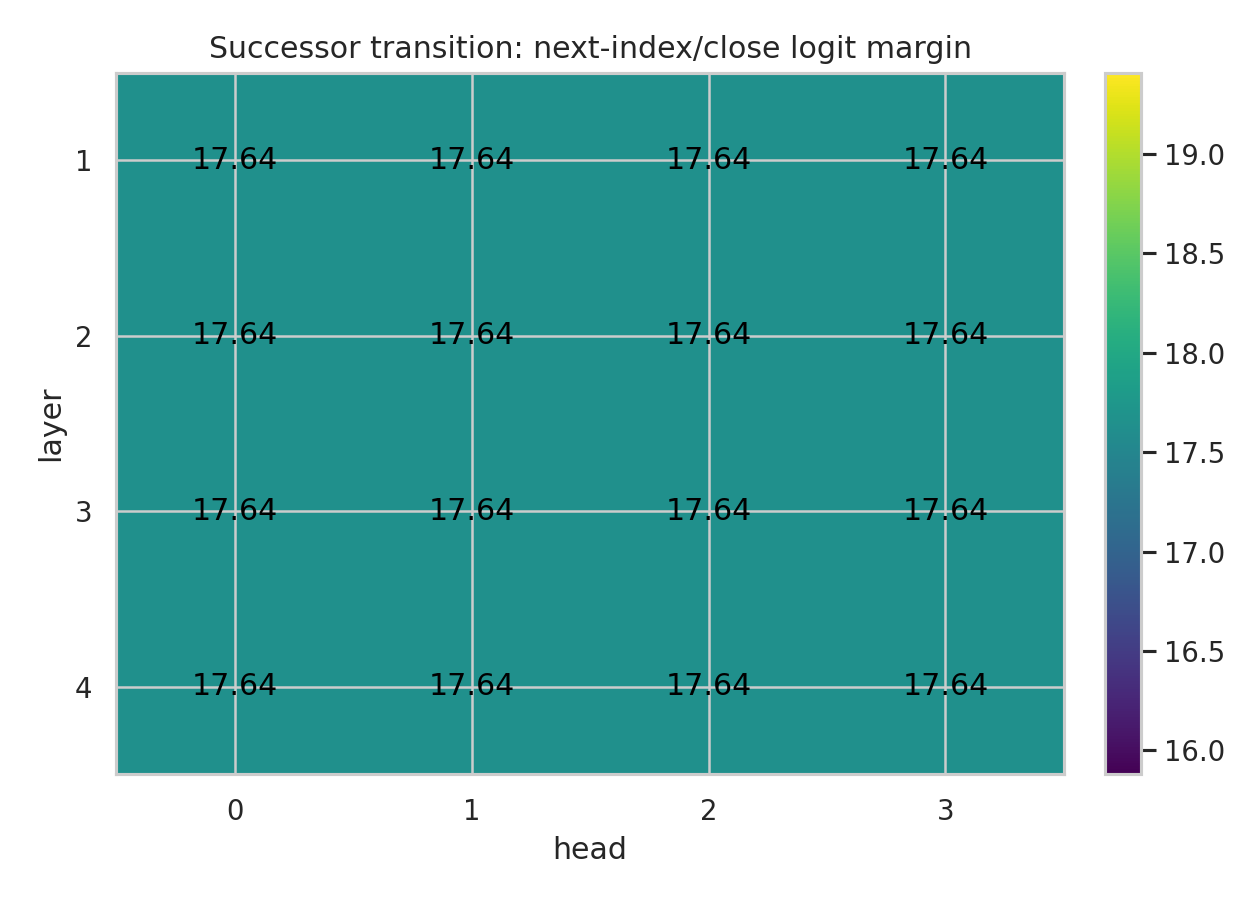

### Successor transition: attention from marker_k to itself
`successor_current_marker_self_mass.png`

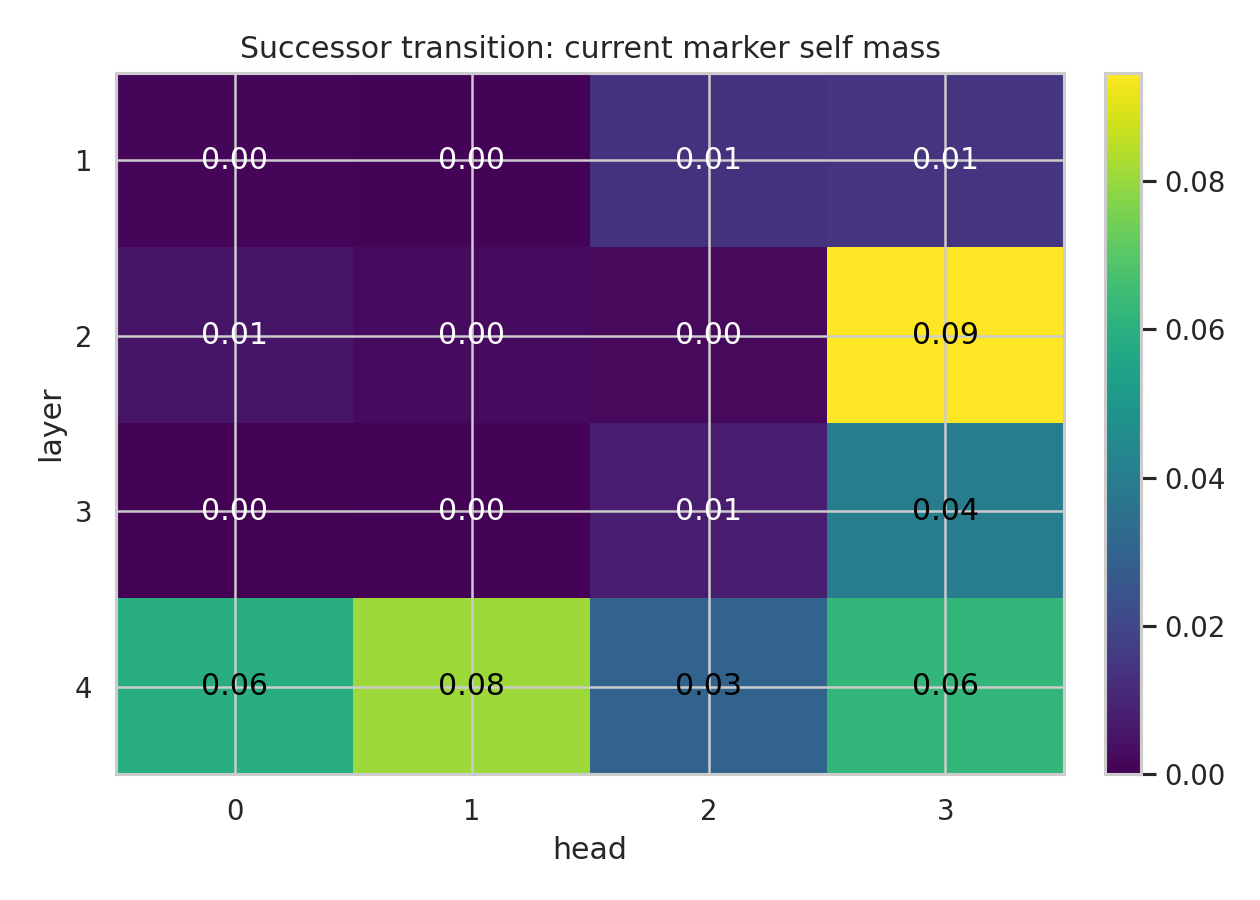

### Successor transition: attention from marker_k to prompt needle k+1
`successor_next_prompt_needle_mass.png`

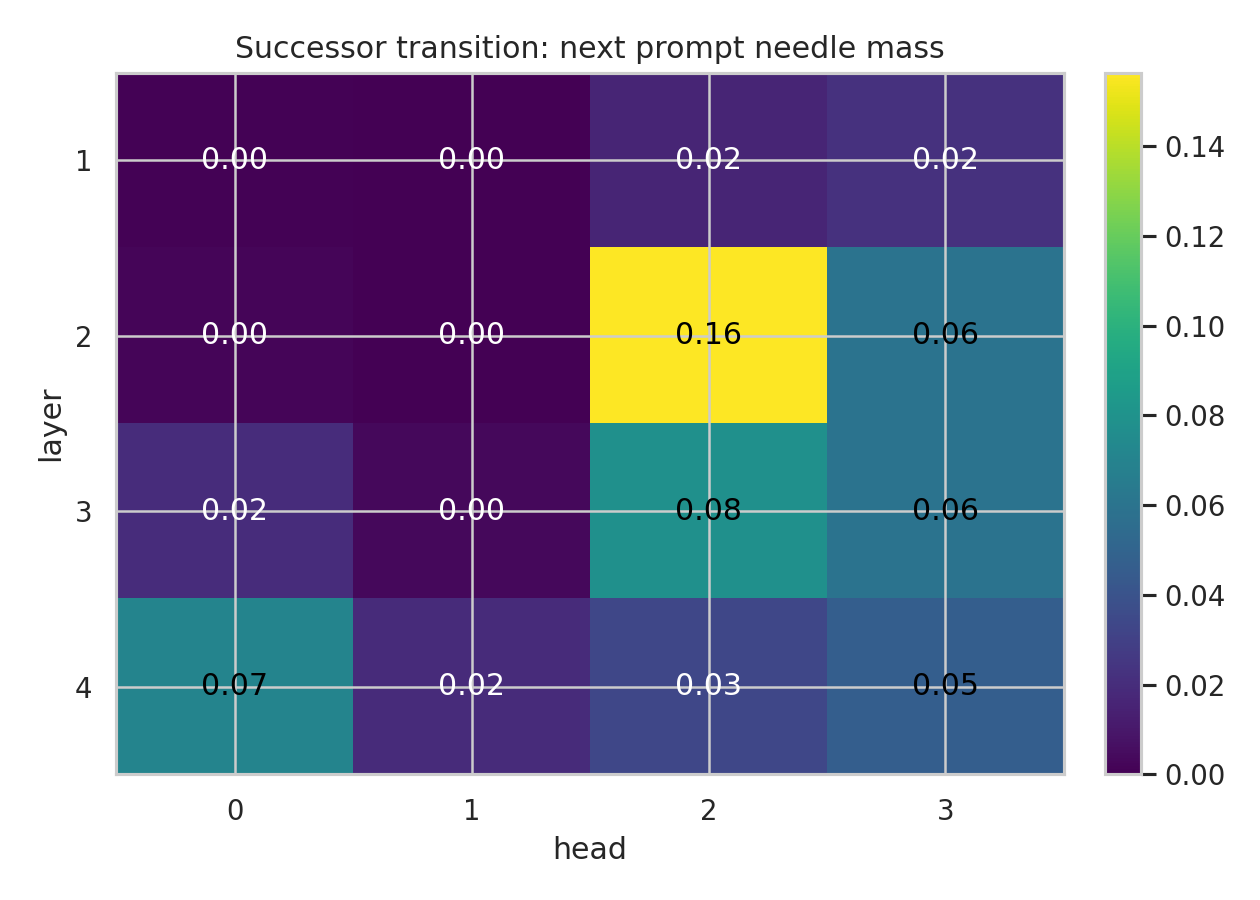

### Next index token: attention mass to prompt needle k
`next_index_correct_prompt_needle_mass.png`

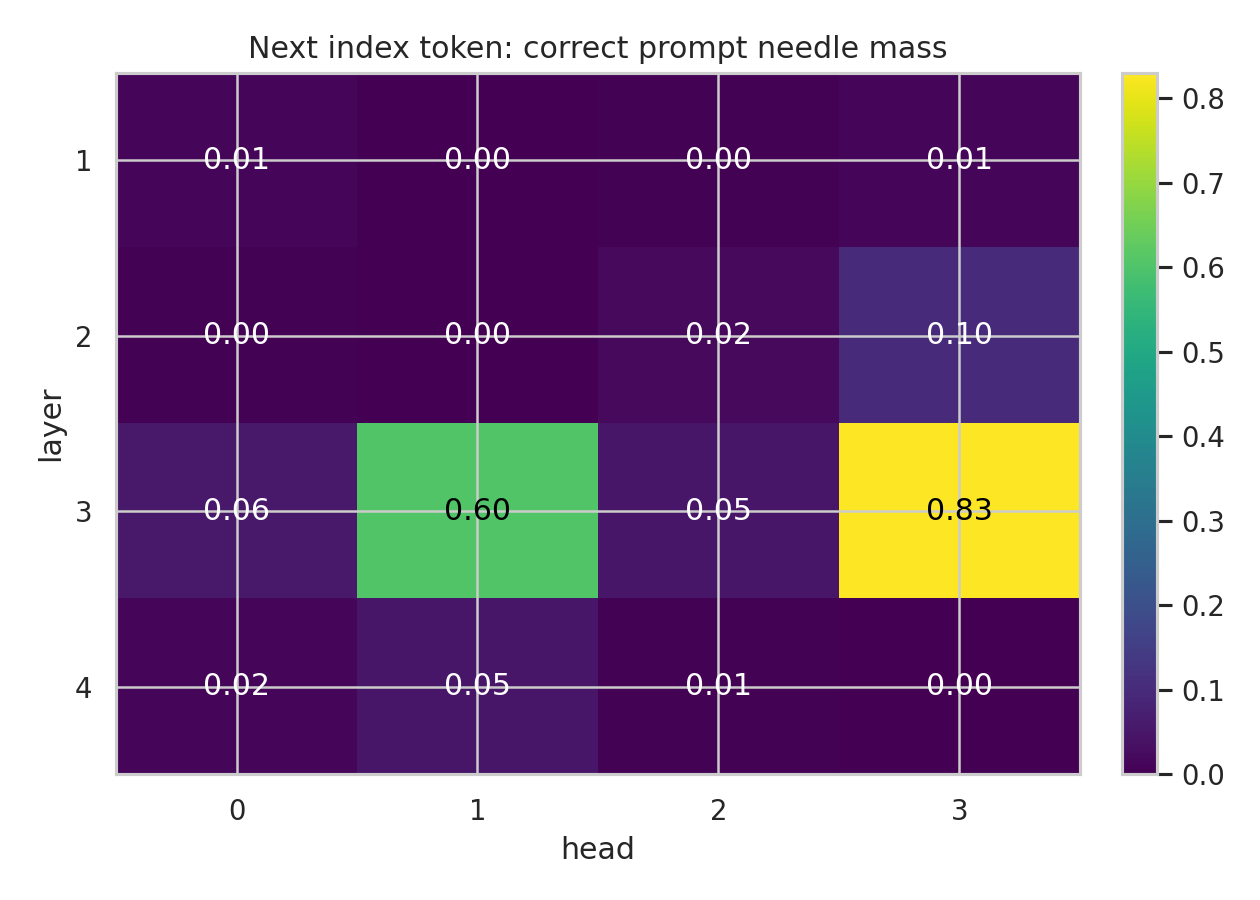

### Next index token: whether the correct prompt needle is top-1 among prompt needles
`next_index_correct_top1.png`

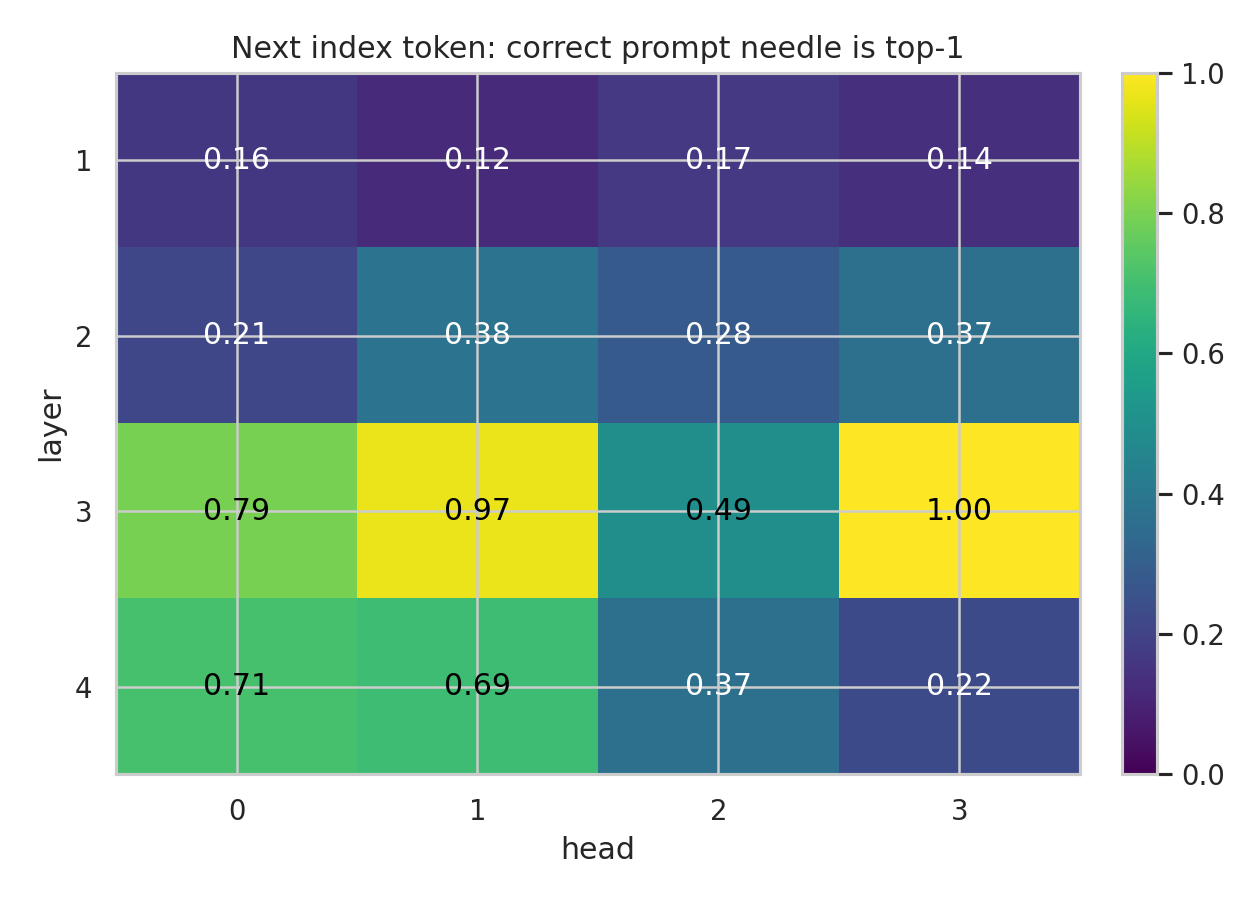

### Single-head ablation: drop in successor next-index/close margin
`successor_margin_drop_by_head.png`

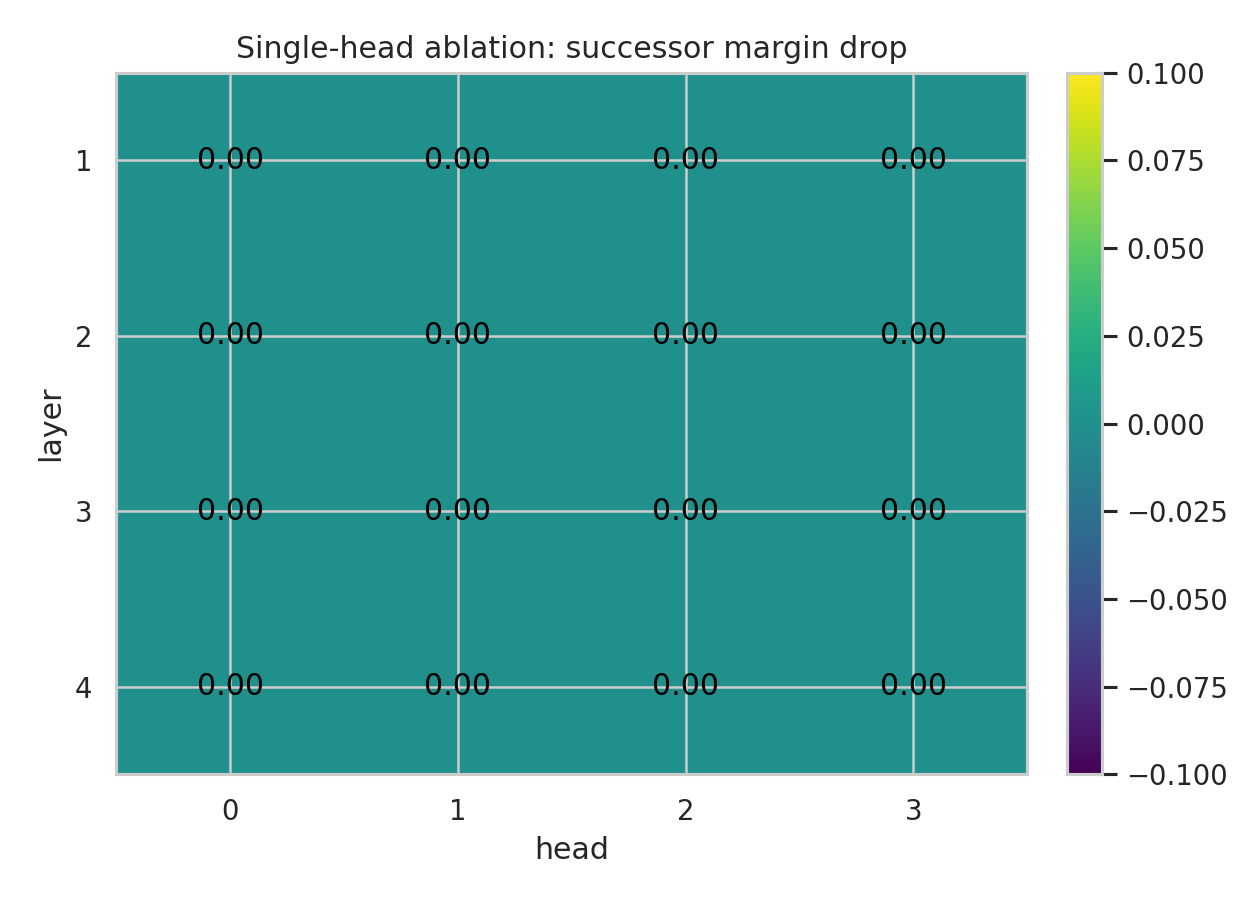

### Final answer: attention mass from <Ans> to all trace markers
`answer_all_trace_marker_mass.png`

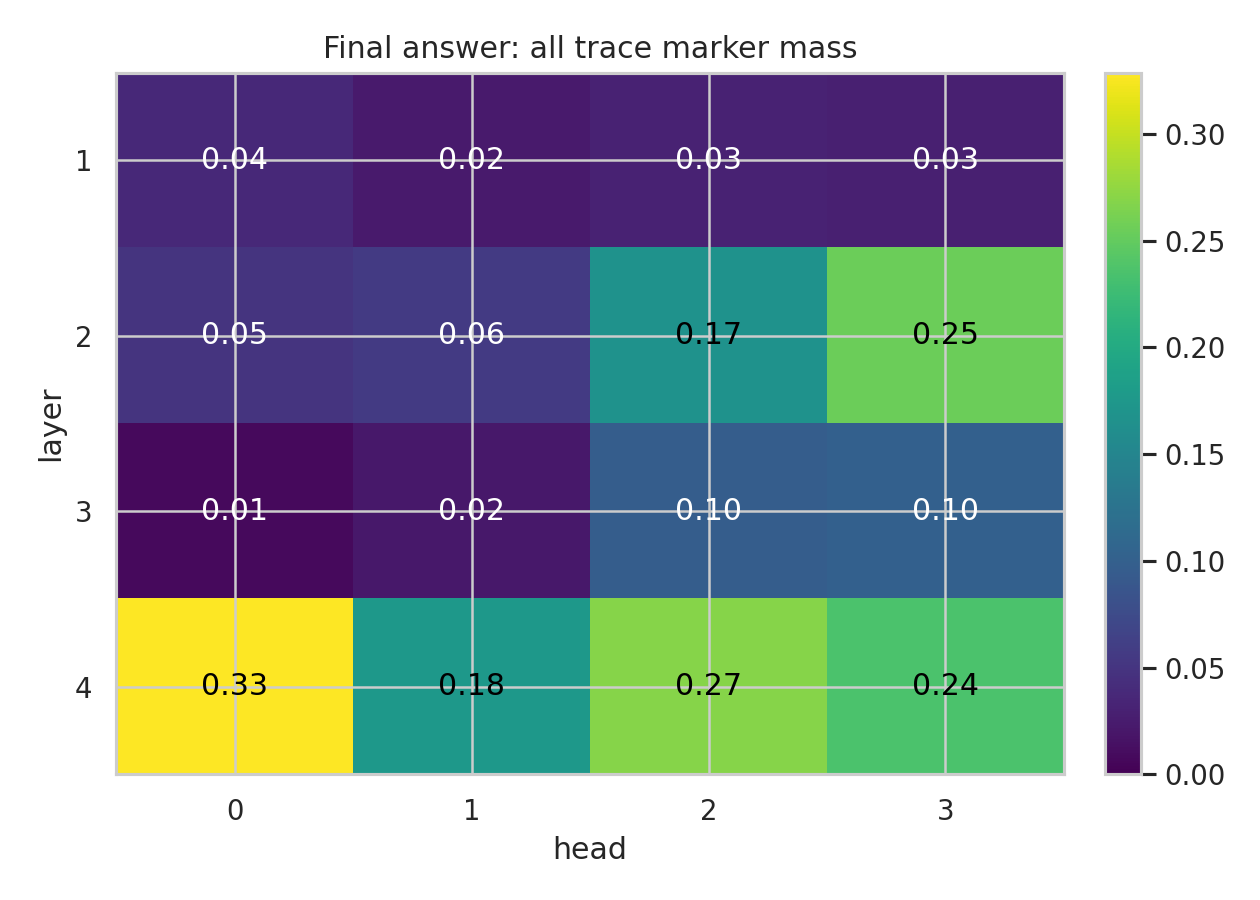

### Final answer: attention mass from <Ans> to the last trace marker
`answer_last_trace_marker_mass.png`

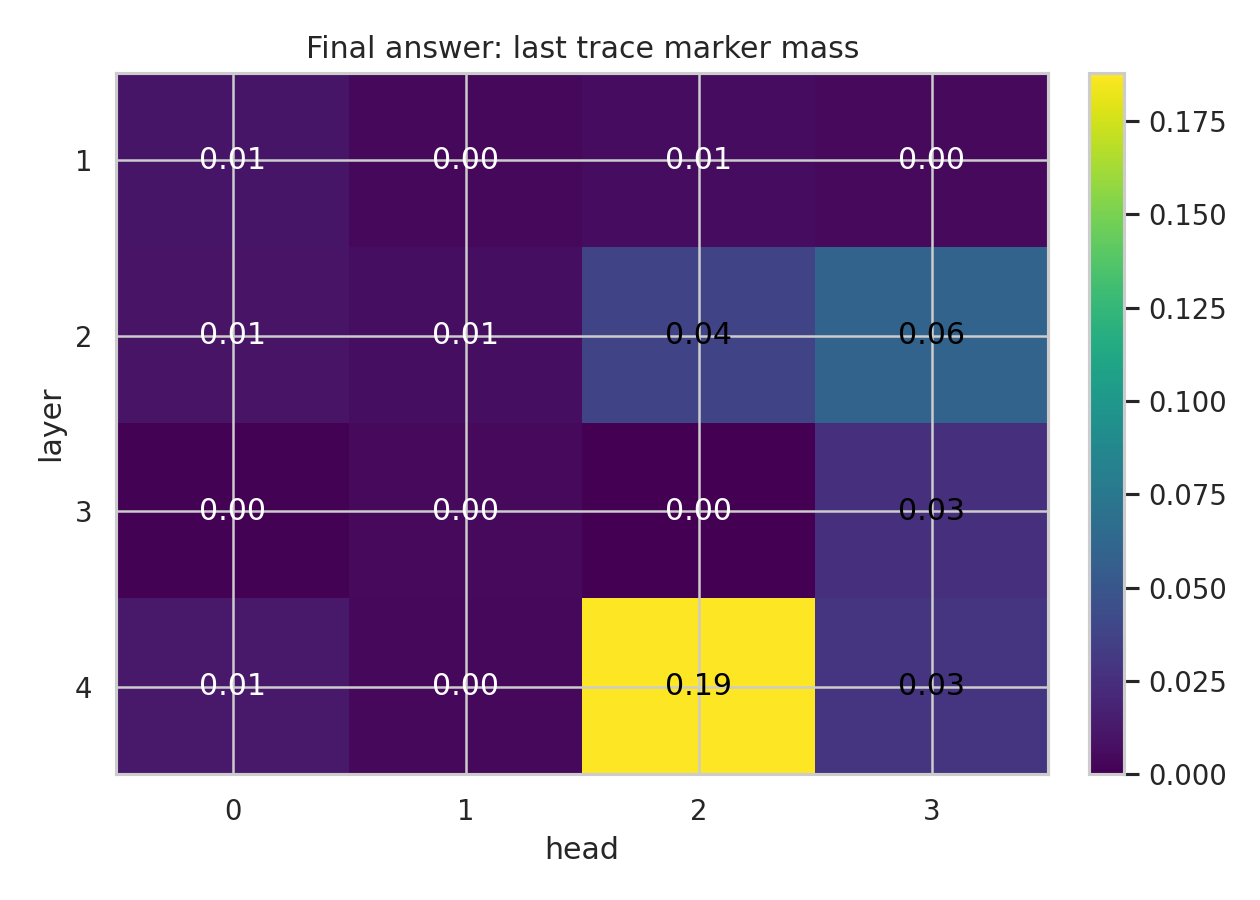

### Final answer multi-head mask: count-margin drop
`answer_multihead_mask_margin_drop.png`

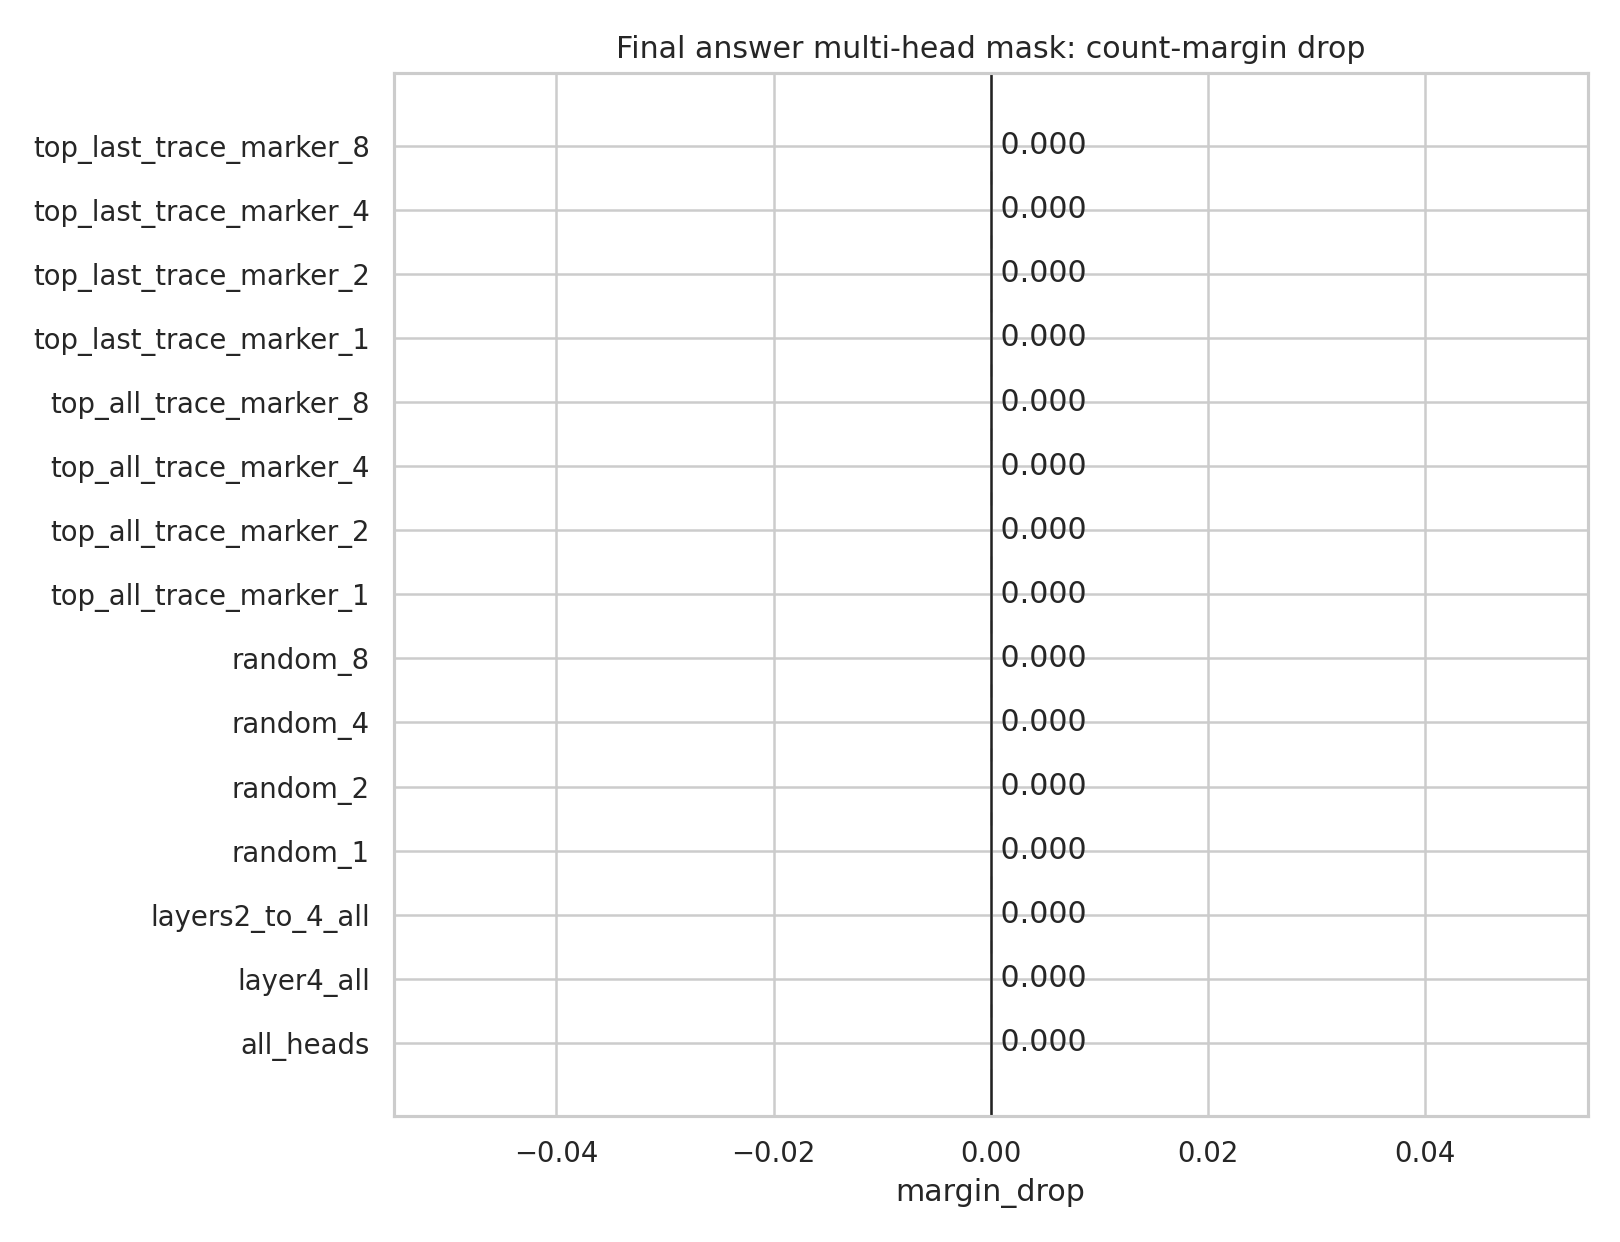

### Final answer multi-head mask: accuracy drop
`answer_multihead_mask_accuracy_drop.png`

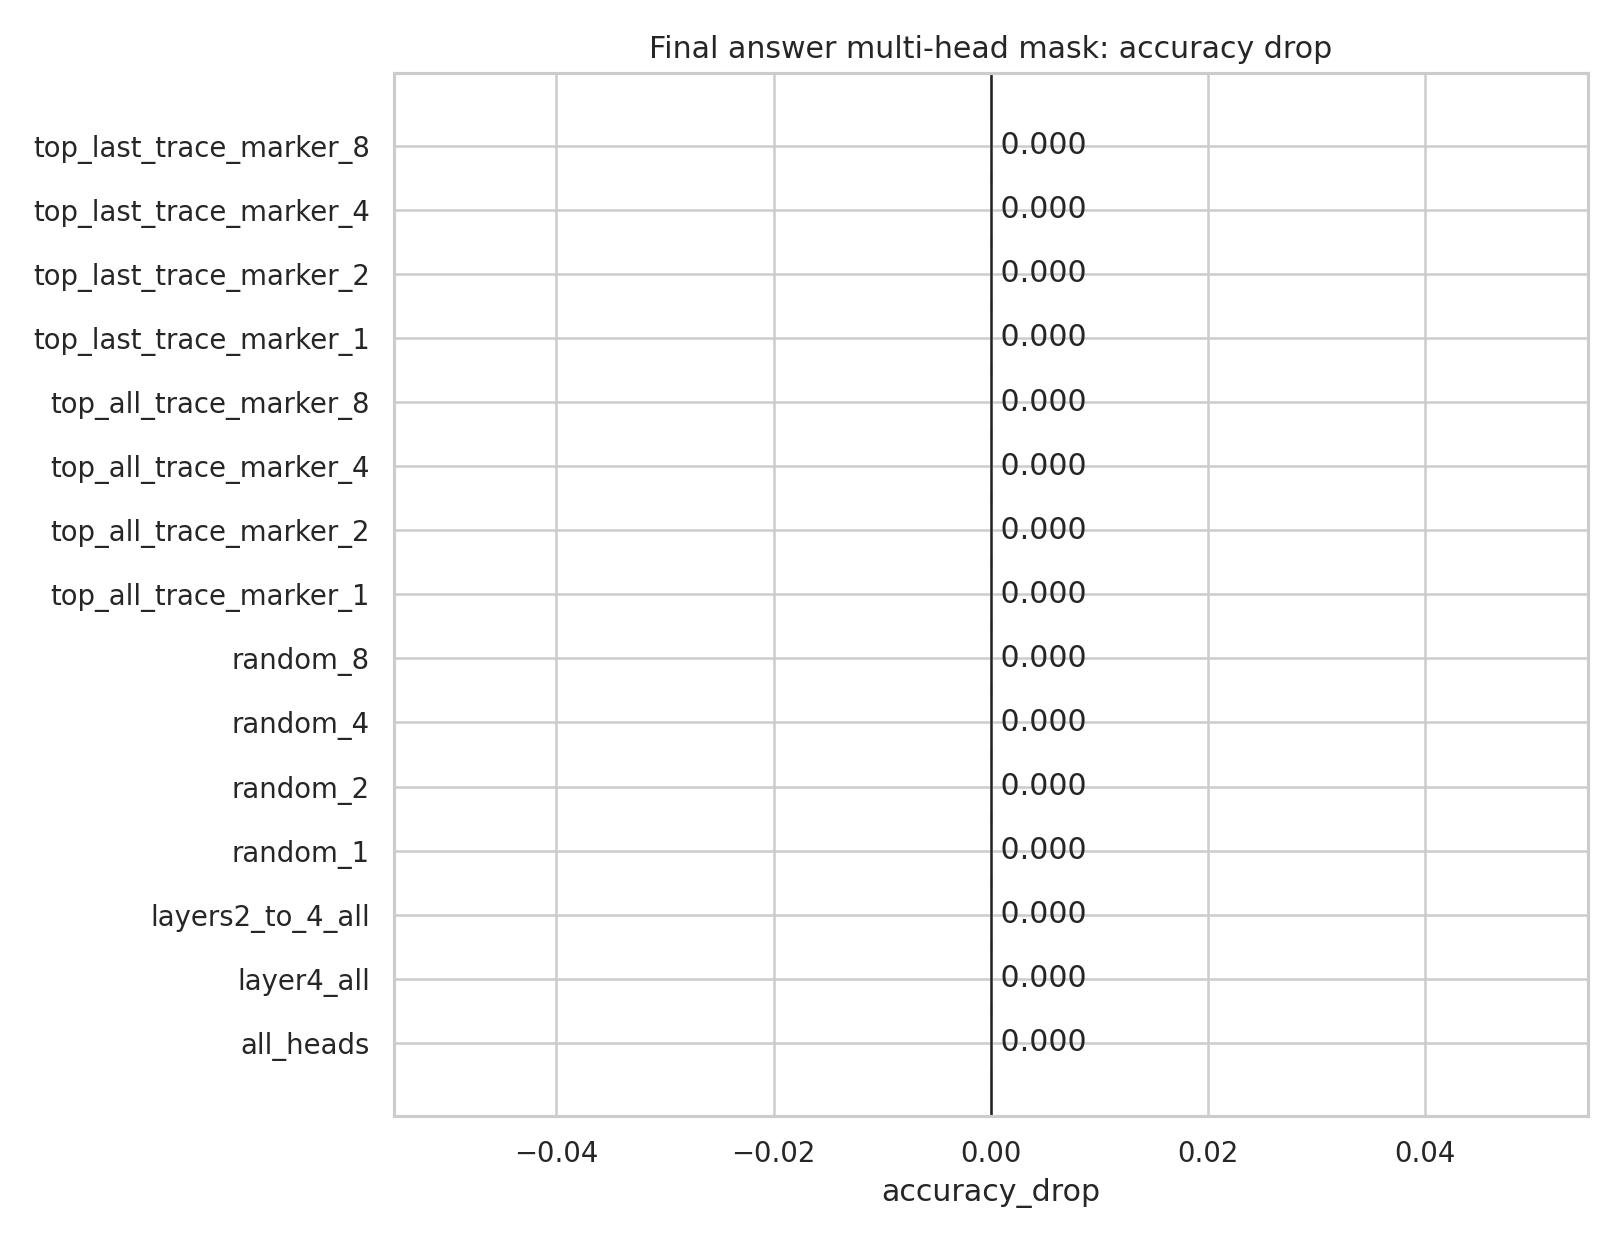

### Trace-length override: whether final answer follows forced trace length
`trace_length_override_follows_trace.png`

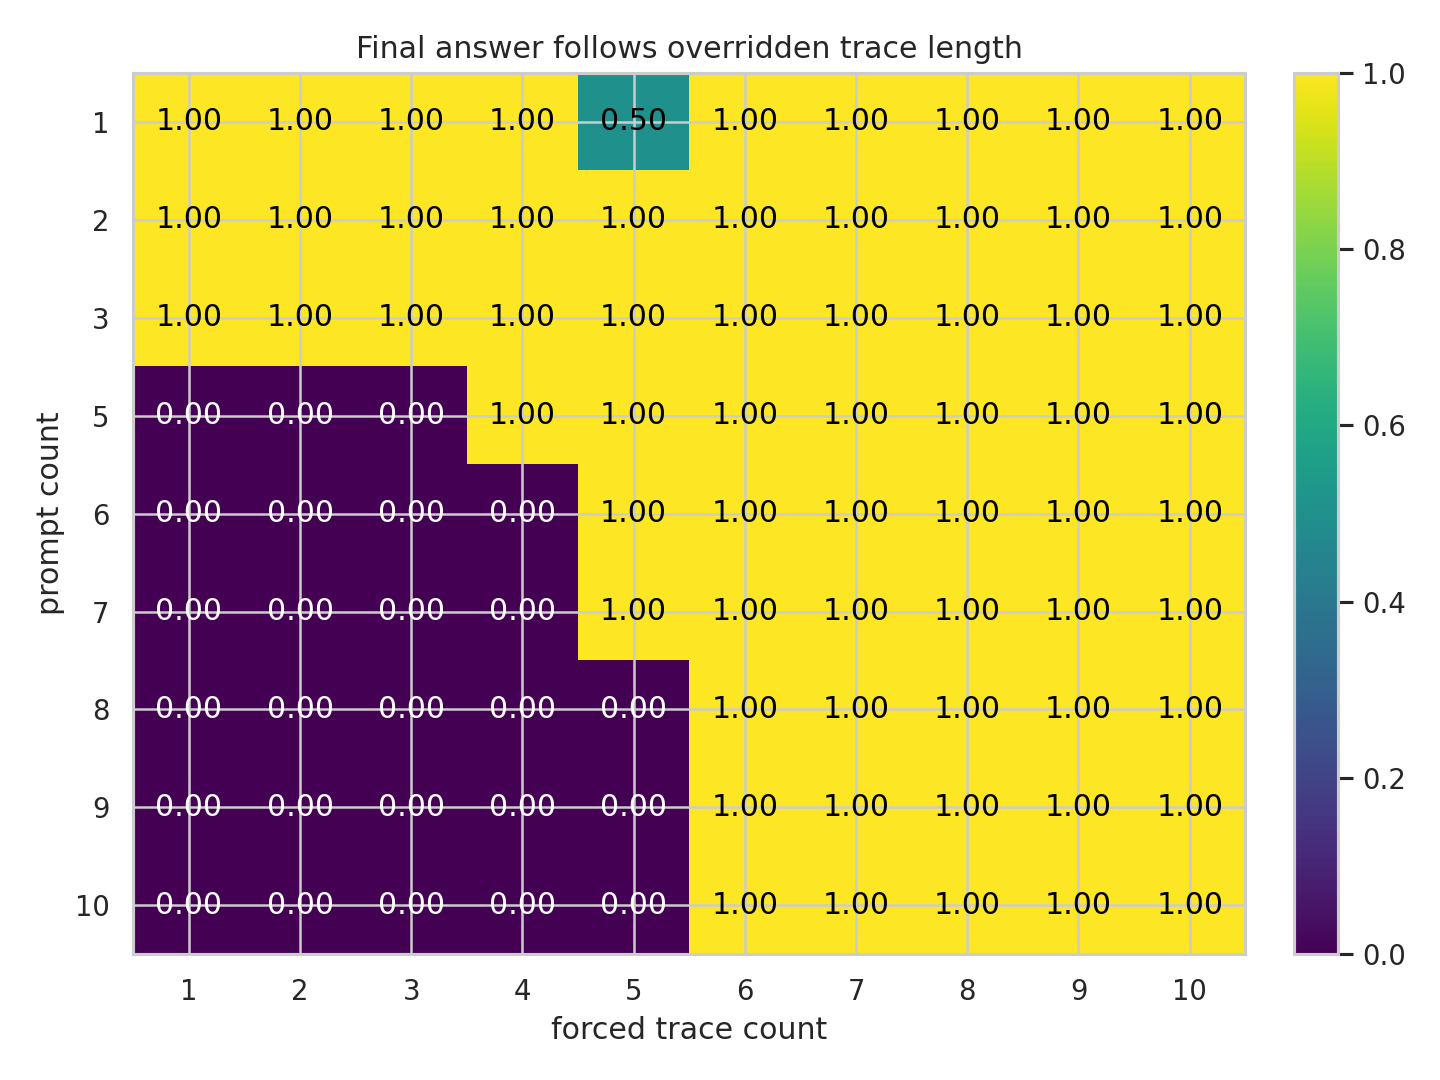

In [20]:
if RUN_FOLLOWUP_MECHANISM:
    fig_dir = FOLLOWUP_DIR / "figures"
    followup_figs = [
        ("successor_next_token_margin.png", "Successor transition: next-index/close logit margin by layer/head"),
        ("successor_current_marker_self_mass.png", "Successor transition: attention from marker_k to itself"),
        ("successor_next_prompt_needle_mass.png", "Successor transition: attention from marker_k to prompt needle k+1"),
        ("next_index_correct_prompt_needle_mass.png", "Next index token: attention mass to prompt needle k"),
        ("next_index_correct_top1.png", "Next index token: whether the correct prompt needle is top-1 among prompt needles"),
        ("successor_margin_drop_by_head.png", "Single-head ablation: drop in successor next-index/close margin"),
        ("answer_all_trace_marker_mass.png", "Final answer: attention mass from <Ans> to all trace markers"),
        ("answer_last_trace_marker_mass.png", "Final answer: attention mass from <Ans> to the last trace marker"),
        ("answer_multihead_mask_margin_drop.png", "Final answer multi-head mask: count-margin drop"),
        ("answer_multihead_mask_accuracy_drop.png", "Final answer multi-head mask: accuracy drop"),
        ("trace_length_override_follows_trace.png", "Trace-length override: whether final answer follows forced trace length"),
    ]
    for filename, caption in followup_figs:
        path = fig_dir / filename
        if path.exists():
            display(Markdown(f"### {caption}\n`{filename}`"))
            display(Image(filename=str(path)))
        else:
            display(Markdown(f"Missing follow-up figure: `{path}`"))
        

## 13. Save Results to Google Drive

In [23]:
DRIVE_SAVE_COMPLETED = False
SAVE_TO_DRIVE = True
DRIVE_RESULTS_ROOT = Path("/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results")

if SAVE_TO_DRIVE:
    if not IN_COLAB:
        raise RuntimeError("Google Drive save is intended for Colab. Set SAVE_TO_DRIVE=False locally.")
    from google.colab import drive
    drive.mount("/content/drive")
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    dest = DRIVE_RESULTS_ROOT / f"v2_2_attention_diagnostics_seed{RANDOM_SEED}_{stamp}"
    dest.mkdir(parents=True, exist_ok=True)
    shutil.copytree(ANALYSIS_DIR, dest / "analysis", dirs_exist_ok=True)
    if "FOLLOWUP_DIR" in globals() and FOLLOWUP_DIR is not None and FOLLOWUP_DIR.exists():
        shutil.copytree(FOLLOWUP_DIR, dest / "followup_mechanism", dirs_exist_ok=True)
    nb_src = ROOT / "notebooks" / "Trace_Count_v2_2_Colab.ipynb"
    if nb_src.exists():
        shutil.copy2(nb_src, dest / nb_src.name)
    (dest / "manifest.json").write_text(json.dumps({
        "source_v2_run_dir": str(V2_RUN_DIR),
        "analysis_dir": str(ANALYSIS_DIR),
        "examples_per_count": EXAMPLES_PER_COUNT,
        "followup_examples_per_count": globals().get("FOLLOWUP_EXAMPLES_PER_COUNT"),
        "followup_causal_examples_per_count": globals().get("FOLLOWUP_CAUSAL_EXAMPLES_PER_COUNT"),
        "followup_dir": str(FOLLOWUP_DIR) if "FOLLOWUP_DIR" in globals() and FOLLOWUP_DIR is not None else None,
        "focus_layer": FOCUS_LAYER,
        "head_scope": "all heads in focus_layer",
        "created_at": datetime.now().isoformat(),
    }, indent=2), encoding="utf-8")
    DRIVE_SAVE_COMPLETED = True
    display(Markdown(f"Saved v2.2 results to Drive: `{dest}`"))
else:
    display(Markdown(f"Drive save skipped. Local analysis dir: `{ANALYSIS_DIR}`"))
        

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saved v2.2 results to Drive: `/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results/v2_2_attention_diagnostics_seed1234_20260709_212435`

## 14. Optional: Disconnect Colab Runtime After Drive Save

In [24]:
AUTO_DISCONNECT_AFTER_SAVE = False

if AUTO_DISCONNECT_AFTER_SAVE:
    if IN_COLAB and DRIVE_SAVE_COMPLETED:
        from google.colab import runtime
        runtime.unassign()
    else:
        print("Not disconnecting: either not in Colab or DRIVE_SAVE_COMPLETED is False.")
        